# Predicción de falla cardíaca con pipelines de aprendizaje automático

Proyecto integrador de aprendizaje automático, capítulo 10 (*Pipelines*) · Machine Learning (maestría) · Prof. Dr. Lihki Rubio

## Resumen

Las enfermedades cardiovasculares son la primera causa de muerte en el mundo y su detección temprana condiciona el pronóstico de los pacientes. Este trabajo desarrolla, de extremo a extremo y en un entorno local, el ciclo de vida de un clasificador binario que estima el riesgo de enfermedad cardíaca (`HeartDisease = 1`) a partir de once variables clínicas de rutina del conjunto *Heart Failure Prediction* (918 pacientes).

El análisis exploratorio revela que 172 registros de colesterol están codificados como cero y que esa ausencia se asocia con una prevalencia de enfermedad del 88.4 %, lo que motiva un preprocesamiento que imputa con la mediana de entrenamiento y conserva un indicador de ausencia. Todo el preprocesamiento se encapsula junto con el clasificador en un `Pipeline` optimizado con `GridSearchCV` y validación cruzada estratificada. Una serie de experimentos controlados separa tres mecanismos de fuga de datos: la variable con fuga de objetivo del enunciado lleva el AUC a 1.000 incluso dentro del `Pipeline`; el preprocesamiento no supervisado ajustado con todos los datos introduce un sesgo inferior a 10⁻⁴; y la selección de variables previa a la validación cruzada fabrica un AUC de 0.707 sobre etiquetas sin señal.

De nueve clasificadores vistos en el curso, el modelo seleccionado es un XGBoost que alcanza en el conjunto de prueba un **AUC de 0.935** (IC 95 %: 0.895–0.969), una **exactitud de 0.897**, una sensibilidad de 0.912 y una especificidad de 0.878. El modelo se sirve mediante una API REST con FastAPI, se empaqueta en una imagen Docker, se despliega en Kubernetes local con Minikube, se verifica en cada cambio con GitHub Actions y se vigila con reportes de deriva de datos generados con Evidently.

## Datos y objetivo

| Aspecto | Descripción |
|---|---|
| Fuente | [Heart Failure Prediction Dataset](https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction) (fedesoriano, 2021), que integra las bases de Cleveland, Hungría, Suiza, Long Beach VA y Statlog del repositorio UCI |
| Universo | 918 pacientes, sin duplicados ni valores `NaN` explícitos |
| Variable objetivo | `HeartDisease` (1 = enfermedad cardíaca, 55.3 %; 0 = sin enfermedad, 44.7 %) |
| Predictores | 6 numéricos (`Age`, `RestingBP`, `Cholesterol`, `FastingBS`, `MaxHR`, `Oldpeak`) y 5 categóricos (`Sex`, `ChestPainType`, `RestingECG`, `ExerciseAngina`, `ST_Slope`) |
| Partición | 80/20 estratificada, semilla 42 (734 / 184 pacientes), realizada antes de cualquier transformación |

## Organización del libro

| Capítulo | Etapa del enunciado | Contenido |
|---|---|---|
| Parte I | 1. Análisis exploratorio y preprocesamiento | EDA, estrategia de preprocesamiento, demostración y diagnóstico de la fuga de datos y comparación de nueve clasificadores |
| Parte II | 2. Entrenamiento seguro | Búsqueda conjunta de modelo e hiperparámetros, matriz de confusión, curva ROC, AUC, sobreajuste, interpretación y exportación |
| Parte III.1 | 3. Despliegue local (FastAPI + Docker) | API REST, imagen de contenedor y evidencia de ejecución |
| Parte III.2 | 4. Orquestación (Kubernetes) | Manifiestos `Deployment` y `Service`, despliegue en Minikube y escalado |
| Parte III.3 | 5. Integración continua (GitHub Actions) | Lint, pruebas automáticas, construcción de la imagen y despliegue en un clúster efímero |
| Parte IV | 6. Monitoreo (Evidently) | Deriva de datos entre entrenamiento, prueba y un lote de producción simulado |
| Síntesis | — | Conclusiones generales y limitaciones |

La estructura de carpetas de la Etapa 0 está en el [repositorio del proyecto](https://github.com/SantiagomezaC/heart-disease-mlops), donde también se encuentra el cuaderno compilado `proyecto_heart_disease_mlops.ipynb`, que reúne todos los capítulos con sus salidas.

## Resultados principales

| Modelo | AUC validación cruzada | AUC prueba | Exactitud prueba |
|---|---|---|---|
| **XGBoost (modelo desplegado)** | **0.939 ± 0.024** | **0.935** | **0.897** |
| Random Forest | 0.934 ± 0.026 | 0.930 | 0.880 |
| Gradient Boosting | 0.934 ± 0.022 | 0.932 | 0.908 |
| k-NN | 0.930 ± 0.032 | 0.939 | 0.908 |
| PCA + SVC (RBF) | 0.929 ± 0.035 | 0.934 | 0.875 |
| Regresión logística | 0.929 ± 0.037 | 0.927 | 0.880 |
| Naive Bayes gaussiano | 0.928 ± 0.035 | 0.927 | 0.886 |
| SVC (RBF) | 0.928 ± 0.036 | 0.935 | 0.880 |
| Árbol de decisión | 0.910 ± 0.028 | 0.887 | 0.777 |

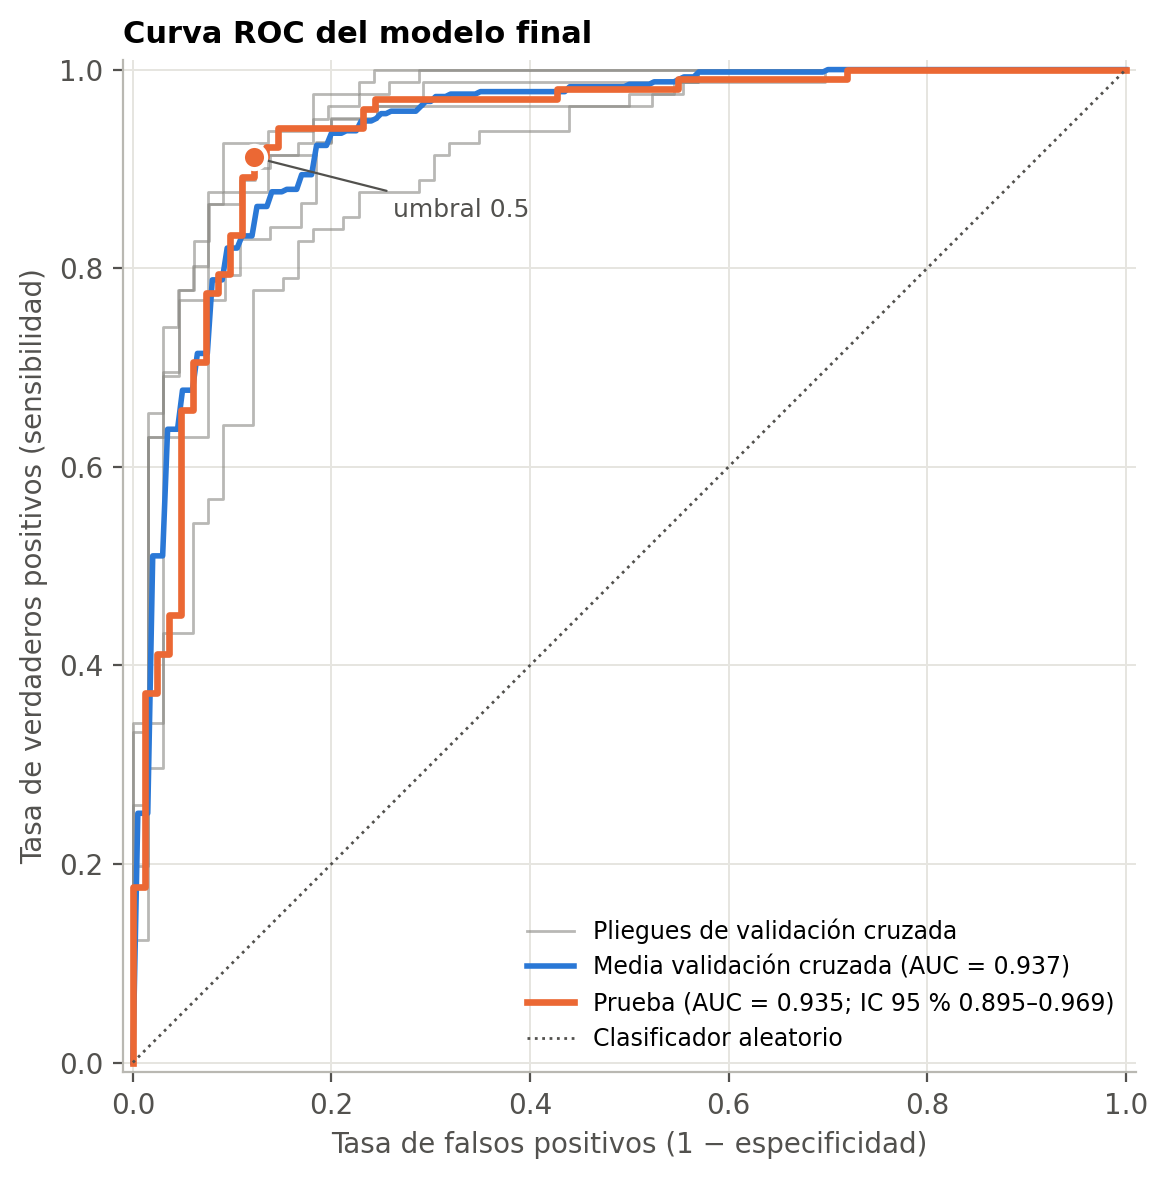

*Curva ROC del modelo desplegado: pliegues de validación cruzada, su promedio y el conjunto de prueba.*

## Criterios metodológicos

La partición estratificada se realiza sobre los datos crudos antes de cualquier transformación, y todas las transformaciones aprendidas (imputación, escalado, codificación y, cuando corresponde, PCA) se ajustan dentro de cada pliegue mediante `Pipeline`. La selección del modelo se basa exclusivamente en el AUC de validación cruzada; el conjunto de prueba se usa una sola vez, al final, y su incertidumbre se cuantifica con intervalos bootstrap. El umbral de decisión de la API es 0.5, como en el enunciado, y su efecto sobre la sensibilidad se analiza con predicciones fuera de pliegue del entrenamiento. Todo el código es determinista (semilla 42) y las dependencias del servicio están fijadas a las mismas versiones con que se entrenó el modelo.

La celda siguiente permite reejecutar el cuaderno desde la raíz del repositorio; las salidas incluidas provienen de la ejecución de cada capítulo en `notebooks/`. Reejecutarlo regenera el modelo y los reportes.

In [ ]:
import os
import sys

os.chdir("notebooks") if os.path.isdir("notebooks") else None
sys.path.insert(0, os.getcwd())

# Parte I. Análisis exploratorio, preprocesamiento y detección de fuga de datos

**Predicción de falla cardíaca con *pipelines* de aprendizaje automático** · Etapa 1 del proyecto integrador

Manuel Meza · Kevin Clemente — Machine Learning (maestría), Prof. Dr. Lihki Rubio — Octubre de 2026

---

**Resumen.** Este cuaderno constituye la Etapa 1 del proyecto integrador de MLOps. Sobre el conjunto *Heart Failure Prediction* (918 pacientes, 11 predictores clínicos) se realiza un análisis exploratorio orientado a decisiones de preprocesamiento, se demuestra experimentalmente cómo y cuándo la fuga de datos (*data leakage*) contamina la evaluación de un clasificador y se comparan nueve modelos vistos en el curso, cada uno encapsulado en un `Pipeline` con `ColumnTransformer` y optimizado mediante `GridSearchCV` con validación cruzada estratificada. Los resultados muestran que una variable con fuga de objetivo lleva el AUC a 1.000 aun cuando el preprocesamiento esté correctamente encapsulado, que la selección de variables realizada antes de la validación cruzada produce un AUC de 0.707 sobre etiquetas sin señal alguna, y que, en el flujo sin fuga, los clasificadores alcanzan AUC de validación cruzada entre 0.910 y 0.939, con diferencias entre los ocho mejores que no superan la incertidumbre muestral del conjunto de prueba.

**Palabras clave:** fuga de datos, `Pipeline`, `ColumnTransformer`, validación cruzada, AUC, falla cardíaca.

## Contenido

1. Introducción
2. Datos y configuración experimental
3. Análisis exploratorio
4. Estrategia de preprocesamiento
5. Fuga de datos: demostración y diagnóstico
6. Comparación de clasificadores sin fuga
7. Conclusiones
8. Referencias

## 1. Introducción

Las enfermedades cardiovasculares son la primera causa de muerte en el mundo según la Organización Mundial de la Salud, y una fracción importante de los eventos podría anticiparse con información clínica de rutina. La digitalización de los registros médicos permite plantear la detección del riesgo como un problema de clasificación binaria supervisada: a partir de variables como la edad, la presión arterial en reposo, el colesterol sérico, la frecuencia cardíaca máxima o la morfología del segmento ST, se busca estimar la probabilidad de que el paciente presente enfermedad cardíaca (`HeartDisease = 1`).

El interés metodológico del capítulo de *pipelines* reside en que el desempeño de un modelo depende tanto del algoritmo como de la representación de los datos, y en que cualquier transformación aprendida de los datos (imputación, escalado, codificación, selección de variables) forma parte del modelo. Si esas transformaciones se ajustan con información del conjunto de evaluación, la estimación del error deja de ser honesta. Este cuaderno examina esa idea de forma empírica antes de pasar al modelado formal de la Etapa 2 (`2_model_pipeline_cv.ipynb`).

## 2. Datos y configuración experimental

El conjunto *Heart Failure Prediction* (fedesoriano, 2021) se descargó de Kaggle y se almacena en `data/heart.csv`. Integra cinco bases históricas del repositorio UCI (Cleveland, Hungría, Suiza, Long Beach VA y Statlog), depuradas de duplicados, para un total de 918 registros. La Tabla 1 resume el diccionario de variables.

**Tabla 1.** Diccionario de variables.

| Variable | Tipo | Descripción | Codificación |
|---|---|---|---|
| `Age` | Numérica | Edad del paciente | años |
| `Sex` | Categórica | Sexo | M, F |
| `ChestPainType` | Categórica | Tipo de dolor torácico | TA: angina típica, ATA: angina atípica, NAP: dolor no anginoso, ASY: asintomático |
| `RestingBP` | Numérica | Presión arterial sistólica en reposo | mm Hg |
| `Cholesterol` | Numérica | Colesterol sérico | mg/dl |
| `FastingBS` | Binaria | Glucemia en ayunas > 120 mg/dl | 1 sí, 0 no |
| `RestingECG` | Categórica | Electrocardiograma en reposo | Normal, ST (anomalía onda ST-T), LVH (hipertrofia ventricular izquierda) |
| `MaxHR` | Numérica | Frecuencia cardíaca máxima alcanzada | latidos/min |
| `ExerciseAngina` | Categórica | Angina inducida por ejercicio | Y, N |
| `Oldpeak` | Numérica | Depresión del segmento ST | mm |
| `ST_Slope` | Categórica | Pendiente del segmento ST en el pico del ejercicio | Up, Flat, Down |
| `HeartDisease` | Objetivo | Presencia de enfermedad cardíaca | 1 sí, 0 no |

Todas las funciones reutilizables del proyecto (carga, partición, preprocesamiento, entrenamiento, evaluación y estilo gráfico) residen en `notebooks/ml_utils.py`, de modo que este cuaderno y el de la Etapa 2 operan con definiciones idénticas. La semilla aleatoria se fija en 42 y la partición de prueba en 20 % estratificada por clase.

In [1]:
import inspect
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from IPython.display import Markdown, display
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GridSearchCV, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC

import ml_utils as mu

warnings.filterwarnings("ignore")
mu.set_plot_style()
pd.set_option("display.precision", 3)
pd.set_option("display.max_columns", 30)
print(f"scikit-learn {sklearn.__version__} · pandas {pd.__version__} · numpy {np.__version__}")

scikit-learn 1.6.1 · pandas 2.2.3 · numpy 1.26.4


In [2]:
df = mu.load_data()
print(f"Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas")
df.head()

Dimensiones: 918 filas × 12 columnas


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


## 3. Análisis exploratorio

### 3.1 Estructura y calidad de los datos

El primer control verifica tipos, valores faltantes explícitos y registros duplicados. Un conjunto sin `NaN` no implica ausencia de datos faltantes: en registros clínicos es frecuente que la falta de medición se codifique como cero, por lo que se cuantifican también los valores fisiológicamente imposibles.

In [3]:
calidad = pd.DataFrame({
    "Tipo": df.dtypes.astype(str),
    "Faltantes (NaN)": df.isna().sum(),
    "Valores = 0": (df == 0).sum(),
    "Valores < 0": df.select_dtypes("number").lt(0).sum().reindex(df.columns),
    "Valores únicos": df.nunique(),
})
print(f"Registros duplicados: {df.duplicated().sum()}")
calidad

Registros duplicados: 0


,Tipo,Faltantes (NaN),Valores = 0,Valores < 0,Valores únicos
Age,int64,0,0,0.0,50
Sex,object,0,0,NaN,2
ChestPainType,object,0,0,NaN,4
RestingBP,int64,0,1,0.0,67
Cholesterol,int64,0,172,0.0,222
FastingBS,int64,0,704,0.0,2
RestingECG,object,0,0,NaN,3
MaxHR,int64,0,0,0.0,119
ExerciseAngina,object,0,0,NaN,2
Oldpeak,float64,0,368,13.0,53


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,918.0,53.511,9.433,28.0,47.00,54.0,60.0,77.0
RestingBP,918.0,132.397,18.514,0.0,120.00,130.0,140.0,200.0
Cholesterol,918.0,198.800,109.384,0.0,173.25,223.0,267.0,603.0
FastingBS,918.0,0.233,0.423,0.0,0.00,0.0,0.0,1.0
MaxHR,918.0,136.809,25.460,60.0,120.00,138.0,156.0,202.0
Oldpeak,918.0,0.887,1.067,-2.6,0.00,0.6,1.5,6.2
HeartDisease,918.0,0.553,0.497,0.0,0.00,1.0,1.0,1.0


No hay `NaN` ni duplicados, pero `Cholesterol` registra 172 ceros (18.7 % de la muestra) y `RestingBP` uno. Ambos valores son incompatibles con la vida y deben interpretarse como mediciones ausentes. Los 368 ceros de `Oldpeak` y sus 13 valores negativos (mínimo −2.6 mm) son, en cambio, clínicamente válidos: la ausencia de depresión del ST es un hallazgo frecuente y la elevación del segmento se reporta con signo negativo. `FastingBS` es binaria, de modo que sus ceros tampoco son faltantes.

La pregunta relevante es si los ceros de colesterol son aleatorios. La tabla siguiente muestra que no lo son.

In [5]:
chol_missing = (df["Cholesterol"] == 0).map({True: "Cholesterol = 0 (ausente)", False: "Cholesterol > 0"})
tabla_ausencia = (df.groupby(chol_missing)["HeartDisease"]
                    .agg(Pacientes="size", **{"Tasa de enfermedad": "mean"}))
tabla_ausencia

,Pacientes,Tasa de enfermedad
Cholesterol,,
Cholesterol = 0 (ausente),172,0.884
Cholesterol > 0,746,0.477


Entre los pacientes sin colesterol registrado la prevalencia de enfermedad es de 88.4 %, frente a 47.7 % en el resto. La ausencia proviene mayoritariamente de la cohorte suiza, compuesta casi por completo por pacientes enfermos, por lo que el mecanismo de faltantes no es completamente aleatorio (MNAR o, al menos, MAR condicionado a la cohorte de origen). Imputar sin más con la mediana destruiría esa señal; por ello el preprocesamiento combinará la imputación con un indicador binario de ausencia (`SimpleImputer(add_indicator=True)`), práctica recomendada cuando el patrón de ausencia es informativo.

### 3.2 Balance de clases

In [6]:
balance = df["HeartDisease"].value_counts().rename(mu.CLASS_LABELS).to_frame("Pacientes")
balance["Proporción"] = balance["Pacientes"] / len(df)
balance

,Pacientes,Proporción
HeartDisease,,
Con enfermedad (1),508,0.553
Sin enfermedad (0),410,0.447


La clase positiva representa el 55.3 % de la muestra (508 frente a 410). El desbalance es leve y no justifica remuestreo; basta con estratificar la partición y los pliegues de validación cruzada para preservar esa proporción. Como el AUC es invariante a la prevalencia, se adopta como métrica principal, complementada con la exactitud (*accuracy*), tal como pide el enunciado.

### 3.3 Variables numéricas según la clase

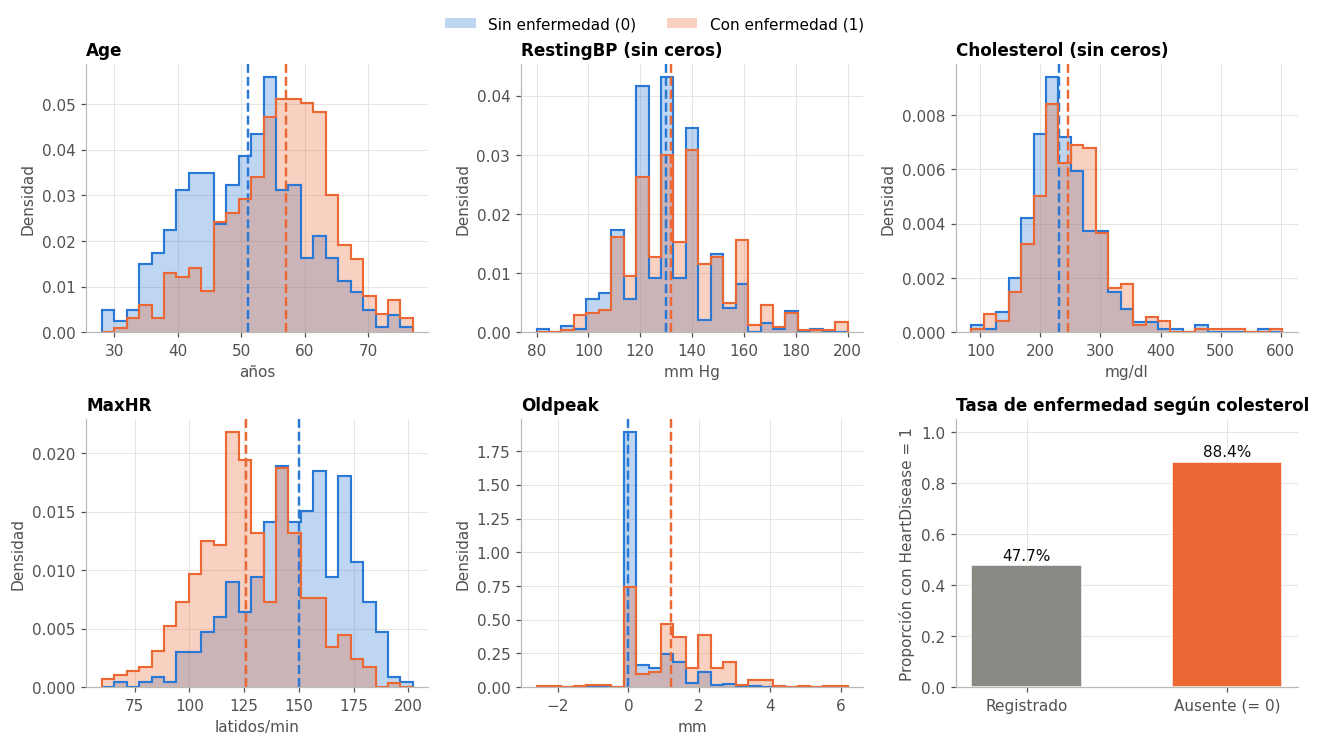

In [7]:
num_vars = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]
unidades = {"Age": "años", "RestingBP": "mm Hg", "Cholesterol": "mg/dl", "MaxHR": "latidos/min", "Oldpeak": "mm"}
fig, axes = plt.subplots(2, 3, figsize=(12, 6.6))
for ax, var in zip(axes.flat, num_vars):
    datos = df[df[var] > 0] if var in mu.ZERO_AS_MISSING else df
    bins = np.histogram_bin_edges(datos[var], bins=25)
    for clase, color in [(0, mu.COLORS["neg"]), (1, mu.COLORS["pos"])]:
        valores = datos.loc[datos.HeartDisease == clase, var]
        ax.hist(valores, bins=bins, color=color, alpha=0.30, density=True, label=mu.CLASS_LABELS[clase])
        ax.hist(valores, bins=bins, color=color, histtype="step", lw=1.4, density=True)
        ax.axvline(datos.loc[datos.HeartDisease == clase, var].median(), color=color, lw=1.6, ls="--")
    nota = " (sin ceros)" if var in mu.ZERO_AS_MISSING else ""
    ax.set_title(f"{var}{nota}")
    ax.set_xlabel(unidades[var])
    ax.set_ylabel("Densidad")
ax = axes.flat[-1]
tasas = df.groupby(df["Cholesterol"] == 0)["HeartDisease"].mean()
ax.bar(["Registrado", "Ausente (= 0)"], [tasas[False], tasas[True]], color=[mu.COLORS["muted"], mu.COLORS["pos"]],
       width=0.55, edgecolor="white")
for i, v in enumerate([tasas[False], tasas[True]]):
    ax.text(i, v + 0.02, f"{v:.1%}", ha="center", color=mu.COLORS["ink"])
ax.set_ylim(0, 1.05)
ax.set_title("Tasa de enfermedad según colesterol")
ax.set_ylabel("Proporción con HeartDisease = 1")
handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.03))
fig.tight_layout()
mu.save_figure(fig, "fig01_numericas_por_clase")
plt.show()

**Figura 1.** Distribución de las variables numéricas por clase (histogramas normalizados; las líneas discontinuas marcan la mediana de cada clase). El último panel compara la prevalencia de enfermedad entre pacientes con y sin colesterol registrado.

Las variables con mayor desplazamiento entre clases son `MaxHR`, cuya mediana desciende de 150 a 126 latidos/min en los pacientes enfermos, y `Oldpeak`, que pasa de 0.0 a 1.2 mm. Ambos comportamientos tienen sustento fisiológico: la incompetencia cronotrópica y la depresión del ST durante el esfuerzo son marcadores clásicos de isquemia. La edad también se desplaza (51 frente a 57 años), mientras que la presión arterial y el colesterol, una vez descontados los ceros, muestran distribuciones casi superpuestas; su aporte directo es débil y, en el caso del colesterol, el contenido informativo reside sobre todo en su ausencia.

### 3.4 Variables categóricas y prevalencia de enfermedad

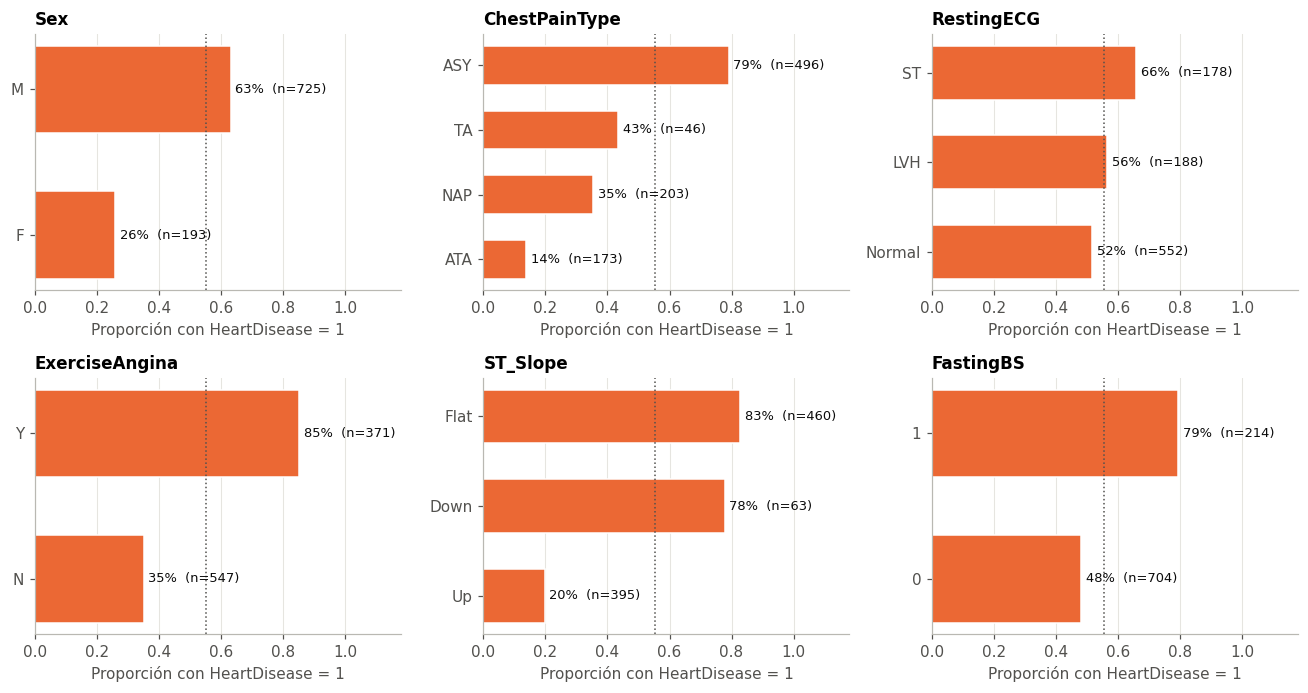

In [8]:
cat_vars = mu.CATEGORICAL + ["FastingBS"]
fig, axes = plt.subplots(2, 3, figsize=(12, 6.4))
prevalencia_global = df["HeartDisease"].mean()
for ax, var in zip(axes.flat, cat_vars):
    resumen = df.groupby(var)["HeartDisease"].agg(["mean", "size"]).sort_values("mean")
    y_pos = np.arange(len(resumen))
    ax.barh(y_pos, resumen["mean"], color=mu.COLORS["pos"], height=0.6, edgecolor="white")
    ax.set_yticks(y_pos, [str(i) for i in resumen.index])
    ax.axvline(prevalencia_global, color=mu.COLORS["ink2"], lw=1, ls=":")
    for yy, (m, n) in enumerate(zip(resumen["mean"], resumen["size"])):
        ax.text(m + 0.015, yy, f"{m:.0%}  (n={n})", va="center", fontsize=8.5, color=mu.COLORS["ink"])
    ax.set_xlim(0, 1.18)
    ax.set_title(var)
    ax.set_xlabel("Proporción con HeartDisease = 1")
    ax.grid(axis="y", visible=False)
fig.tight_layout()
mu.save_figure(fig, "fig02_categoricas_prevalencia")
plt.show()

**Figura 2.** Prevalencia de enfermedad por categoría; la línea punteada indica la prevalencia global (55.3 %) y entre paréntesis se reporta el tamaño de cada grupo.

Las categóricas concentran el mayor poder discriminante del conjunto. La pendiente del ST plana o descendente se asocia con prevalencias de 82.8 % y 77.8 %, frente a 19.7 % cuando es ascendente; la angina inducida por ejercicio eleva la prevalencia a 85.2 % (35.1 % en su ausencia) y el dolor torácico asintomático (ASY), contraintuitivamente, es la categoría de mayor riesgo (79.0 %), hecho bien documentado en isquemia silente. El sexo masculino (63.2 % frente a 25.9 %) y la glucemia elevada en ayunas (79.4 % frente a 48.0 %) completan el cuadro. `RestingECG`, en contraste, apenas se aparta de la prevalencia global. Ninguna categoría es rara en extremo (la menor, `ChestPainType = TA`, tiene 46 pacientes), lo que permite una codificación one-hot sin agrupar niveles.

### 3.5 Asociación entre variables numéricas

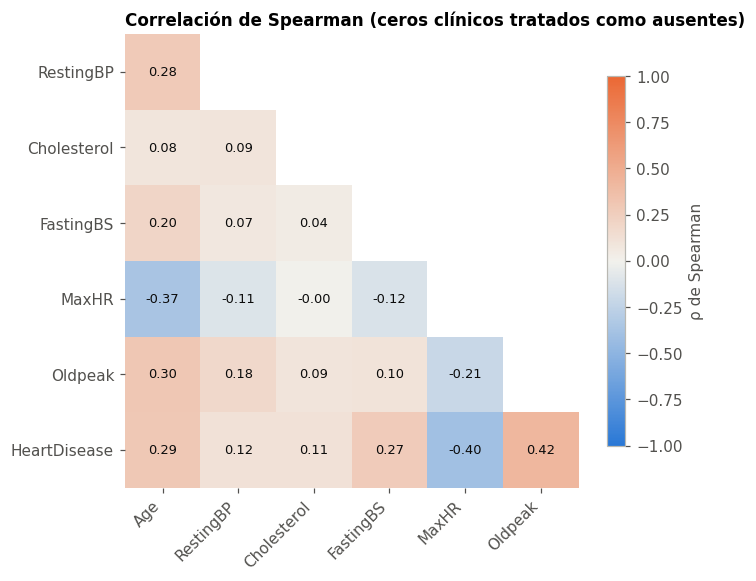

In [9]:
d = df.copy()
for col in mu.ZERO_AS_MISSING:
    d.loc[d[col] == 0, col] = np.nan
corr = d[["Age", "RestingBP", "Cholesterol", "FastingBS", "MaxHR", "Oldpeak", "HeartDisease"]].corr("spearman")
from matplotlib.colors import LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list("div", [mu.COLORS["neg"], "#f2f1ec", mu.COLORS["pos"]])
fig, ax = plt.subplots(figsize=(6.6, 5.4))
mask = np.triu(np.ones_like(corr, dtype=bool), k=0)
im = ax.imshow(np.ma.masked_where(mask, corr), cmap=cmap, vmin=-1, vmax=1)
ax.set_xticks(range(len(corr) - 1), corr.columns[:-1], rotation=45, ha="right")
ax.set_yticks(range(1, len(corr)), corr.columns[1:])
ax.set_xlim(-0.5, len(corr) - 1.5)
ax.set_ylim(len(corr) - 0.5, 0.5)
for i in range(len(corr)):
    for j in range(i):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8.5,
                color="white" if abs(corr.iloc[i, j]) > 0.6 else mu.COLORS["ink"])
ax.grid(False)
for s in ax.spines.values():
    s.set_visible(False)
fig.colorbar(im, ax=ax, shrink=0.8, label="ρ de Spearman")
ax.set_title("Correlación de Spearman (ceros clínicos tratados como ausentes)")
fig.tight_layout()
mu.save_figure(fig, "fig03_correlacion_spearman")
plt.show()

**Figura 3.** Matriz de correlación de Spearman entre variables numéricas y el objetivo, calculada con eliminación por pares de los valores ausentes.

Las asociaciones con el objetivo confirman lo observado en la Figura 1: `Oldpeak` (ρ = 0.42), `MaxHR` (ρ = −0.40), `Age` (ρ = 0.29) y `FastingBS` (ρ = 0.27). Entre predictores, la correlación más alta es la de la edad con la frecuencia cardíaca máxima (ρ = −0.37), coherente con la disminución fisiológica de la reserva cronotrópica. Ningún par supera |ρ| = 0.4, por lo que no hay colinealidad que obligue a descartar variables, y la reducción de dimensionalidad (PCA) se evaluará solo como alternativa dentro del pipeline.

### 3.6 Síntesis del análisis exploratorio

El análisis deja cuatro decisiones de preprocesamiento: (i) los ceros de `Cholesterol` y `RestingBP` se recodifican como ausentes y se imputan con la mediana del conjunto de entrenamiento, acompañados de un indicador de ausencia; (ii) las variables continuas se escalan, requisito para los métodos basados en distancias o márgenes (k-NN, SVM, regresión logística regularizada); (iii) las cinco categóricas nominales se codifican con one-hot; y (iv) toda esta lógica debe ajustarse exclusivamente con datos de entrenamiento, dentro de un `Pipeline`, para que no viaje información del conjunto de evaluación al modelo.

## 4. Estrategia de preprocesamiento

El preprocesamiento se implementa como un `ColumnTransformer` con cuatro ramas, construido por la función `build_preprocessor` de `ml_utils.py`:

| Rama | Columnas | Transformación |
|---|---|---|
| `zero_missing` | `RestingBP`, `Cholesterol` | `SimpleImputer(missing_values=0, strategy="median", add_indicator=True)` → `MinMaxScaler` |
| `num` | `Age`, `MaxHR`, `Oldpeak` | `MinMaxScaler` |
| `bin` | `FastingBS` | sin transformación (ya está en {0, 1}) |
| `cat` | `Sex`, `ChestPainType`, `RestingECG`, `ExerciseAngina`, `ST_Slope` | `OneHotEncoder(drop="if_binary", handle_unknown="ignore")` |

Se conserva el `MinMaxScaler` del enunciado. La codificación one-hot elimina una columna solo en las variables binarias (`Sex`, `ExerciseAngina`), lo que evita la redundancia perfecta sin sacrificar la interpretabilidad de los niveles en las multinomiales; los modelos lineales se usan con regularización, que resuelve la colinealidad residual. La opción `handle_unknown="ignore"` garantiza que una categoría no vista durante el ajuste no detenga la API de inferencia. Usar `SimpleImputer` con `missing_values=0` en lugar de una función propia mantiene el modelo serializado libre de código ajeno a scikit-learn, condición necesaria para cargarlo dentro del contenedor Docker.

In [10]:
print(inspect.getsource(mu.build_preprocessor))

def build_preprocessor(scaler=None) -> ColumnTransformer:
    """Construye el ``ColumnTransformer`` de preprocesamiento.

    * ``RestingBP`` y ``Cholesterol``: el valor 0 se trata como faltante, se
      imputa con la mediana del entrenamiento y se añade un indicador binario
      de ausencia, porque el patrón de ausencia es informativo.
    * Numéricas continuas: escalado (``MinMaxScaler`` por defecto, como en el
      enunciado; puede sustituirse con el argumento ``scaler``).
    * Categóricas nominales: codificación one-hot; ``drop='if_binary'`` evita
      la trampa de la variable ficticia en las binarias y
      ``handle_unknown='ignore'`` protege la inferencia ante categorías nuevas.
    """
    scaler = scaler if scaler is not None else MinMaxScaler()
    zero_missing = Pipeline([
        ("imputer", SimpleImputer(missing_values=0, strategy="median",
                                  add_indicator=True)),
        ("scaler", scaler),
    ])
    numeric = Pipeline([("scaler", sca

In [11]:
X_train, X_test, y_train, y_test = mu.split_data(df)
prep = mu.build_preprocessor().fit(X_train)
nombres = prep.get_feature_names_out()
print(f"Entrenamiento: {X_train.shape}, prueba: {X_test.shape}")
print(f"Prevalencia — entrenamiento: {y_train.mean():.3f}, prueba: {y_test.mean():.3f}")
print(f"Variables tras el preprocesamiento ({len(nombres)}):")
print(list(nombres))

Entrenamiento: (734, 11), prueba: (184, 11)
Prevalencia — entrenamiento: 0.553, prueba: 0.554
Variables tras el preprocesamiento (19):
['zero_missing__RestingBP', 'zero_missing__Cholesterol', 'zero_missing__missingindicator_Cholesterol', 'num__Age', 'num__MaxHR', 'num__Oldpeak', 'bin__FastingBS', 'cat__Sex_M', 'cat__ChestPainType_ASY', 'cat__ChestPainType_ATA', 'cat__ChestPainType_NAP', 'cat__ChestPainType_TA', 'cat__RestingECG_LVH', 'cat__RestingECG_Normal', 'cat__RestingECG_ST', 'cat__ExerciseAngina_Y', 'cat__ST_Slope_Down', 'cat__ST_Slope_Flat', 'cat__ST_Slope_Up']


La partición estratificada conserva la prevalencia (0.553 en entrenamiento y 0.554 en prueba, sobre 734 y 184 pacientes). El preprocesador produce 19 columnas. Conviene notar que solo se genera indicador de ausencia para `Cholesterol`: el único cero de `RestingBP` quedó en el conjunto de prueba, de modo que el imputador ajustado con entrenamiento no observó faltantes en esa columna. Si ese valor llega a inferencia, se imputará igualmente con la mediana de entrenamiento; este es precisamente el comportamiento correcto de un transformador ajustado sin mirar la prueba.

## 5. Fuga de datos: demostración y diagnóstico

La fuga de datos ocurre cuando el proceso de entrenamiento accede, directa o indirectamente, a información que no estaría disponible al momento de predecir. Conviene distinguir dos mecanismos: la **fuga de objetivo**, en la que un predictor codifica el desenlace (por ejemplo, una variable registrada después del diagnóstico), y la **fuga de preprocesamiento o de validación**, en la que un paso aprendido (escalado, imputación, selección de variables) se ajusta con datos que luego se usan para evaluar. Los experimentos siguientes ilustran ambos.

### 5.1 Réplica del experimento propuesto en el enunciado

Se reproduce el código del enunciado con dos adaptaciones mínimas impuestas por el conjunto de Kaggle: el objetivo se llama `HeartDisease` (no `target`) y las cinco variables categóricas se convierten a indicadoras con `pd.get_dummies` para que `MinMaxScaler` y `SVC` puedan operar sobre una matriz numérica, como en el ejemplo original.

In [12]:
# Datos en formato numérico, como en el ejemplo del enunciado
X = pd.get_dummies(df.drop("HeartDisease", axis=1), drop_first=True, dtype=float)
y = df["HeartDisease"]

# Variable artificial que introduce fuga
np.random.seed(0)
X["leaky_feature"] = y + np.random.normal(0, 0.01, size=len(y))


def demo_enunciado(X, y):
    # Ejemplo con fuga de datos (data leakage)
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)
    X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

    grid_l = GridSearchCV(SVC(probability=True), param_grid={"C": [0.1, 1, 10], "gamma": [0.01, 0.1]},
                          cv=5, scoring="roc_auc")
    grid_l.fit(X_train_l, y_train_l)
    auc_l = roc_auc_score(y_test_l, grid_l.predict_proba(X_test_l)[:, 1])

    # Flujo correcto (sin fuga)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    pipe = Pipeline([("scaler", MinMaxScaler()), ("svc", SVC(probability=True))])
    param_grid = {"svc__C": [0.1, 1, 10], "svc__gamma": [0.01, 0.1]}
    grid = GridSearchCV(pipe, param_grid, cv=5, scoring="roc_auc")
    grid.fit(X_train, y_train)
    auc = roc_auc_score(y_test, grid.predict_proba(X_test)[:, 1])
    return auc_l, auc


auc_l, auc = demo_enunciado(X, y)
print(f"AUC con fuga: {auc_l:.3f}")
print(f"AUC sin fuga: {auc:.3f}")

AUC con fuga: 1.000
AUC sin fuga: 1.000


Ambos flujos alcanzan un AUC de 1.000. El resultado es instructivo precisamente porque contradice la intuición de que el `Pipeline` «corrige» la fuga: `leaky_feature` se construyó como el objetivo más un ruido de desviación 0.01, de modo que está presente en entrenamiento y en prueba y separa las clases sin error. Encapsular el escalado protege contra la fuga de preprocesamiento, pero no puede detectar que un predictor contenga la respuesta. Esa responsabilidad corresponde a la auditoría de variables, que se aborda a continuación.

### 5.2 Detección de fuga de objetivo mediante auditoría univariada

Un procedimiento simple y efectivo consiste en calcular, sobre el conjunto de entrenamiento, el AUC de cada predictor tomado aisladamente. En problemas clínicos reales es excepcional que una sola variable discrimine casi a la perfección; un AUC univariado mayor que 0.95 (o menor que 0.05) se trata como alerta. La función `univariate_auc_audit` implementa esta regla (las categóricas se representan por la tasa de positivos de su nivel).

In [13]:
X_aud = df[mu.FEATURES].copy()
X_aud["leaky_feature"] = X["leaky_feature"]
X_aud_train, _, y_aud_train, _ = train_test_split(X_aud, y, test_size=0.2, stratify=y, random_state=42)
auditoria = mu.univariate_auc_audit(X_aud_train, y_aud_train)
auditoria

,Variable,AUC univariado,Poder discriminante |AUC-0.5|,Sospecha de fuga
0,leaky_feature,1.000,0.500,Sí
1,ST_Slope,0.823,0.323,No
2,ChestPainType,0.784,0.284,No
3,ExerciseAngina,0.743,0.243,No
4,MaxHR,0.262,0.238,No
5,Oldpeak,0.719,0.219,No
6,Age,0.648,0.148,No
7,Sex,0.615,0.115,No
8,FastingBS,0.610,0.110,No
9,Cholesterol,0.417,0.083,No


La auditoría aísla `leaky_feature` con AUC = 1.000, mientras que el predictor legítimo más fuerte, `ST_Slope`, se queda en torno a 0.82, y ninguna otra variable supera 0.80. La variable se elimina y el experimento del enunciado se repite sobre los once predictores originales.

In [14]:
auc_l_limpio, auc_limpio = demo_enunciado(X.drop(columns="leaky_feature"), y)
print(f"AUC con fuga de preprocesamiento: {auc_l_limpio:.4f}")
print(f"AUC sin fuga (Pipeline):          {auc_limpio:.4f}")

AUC con fuga de preprocesamiento: 0.9215
AUC sin fuga (Pipeline):          0.9215


### 5.3 Magnitud de la fuga de preprocesamiento en este conjunto

Sin la variable artificial, los dos flujos del enunciado producen el mismo AUC hasta la cuarta cifra decimal (0.9215). La explicación es casi determinista y conviene verificarla: `MinMaxScaler` solo aprende el mínimo y el máximo de cada columna, de manera que, si los extremos de la muestra completa caen en la partición de entrenamiento, el escalador ajustado con todos los datos coincide con el ajustado solo con entrenamiento.

In [15]:
Xn = X.drop(columns="leaky_feature")
Xn_train, Xn_test = train_test_split(Xn, test_size=0.2, random_state=42)
s_total = MinMaxScaler().fit(Xn)
s_train = MinMaxScaler().fit(Xn_train)
coinciden = np.isclose(s_total.data_min_, s_train.data_min_) & np.isclose(s_total.data_max_, s_train.data_max_)
print(f"Columnas con mínimo y máximo idénticos (total vs. entrenamiento): {coinciden.sum()} de {len(coinciden)}")
print("Columnas que difieren:", list(Xn.columns[~coinciden]))

Columnas con mínimo y máximo idénticos (total vs. entrenamiento): 14 de 15
Columnas que difieren: ['Age']


Con esa semilla, 14 de las 15 columnas tienen extremos idénticos en ambos ajustes; solo difiere `Age`, cuyo rango cambia en uno de sus bordes. El efecto es un reescalado afín marginal de una sola variable, insuficiente para alterar el ordenamiento de las probabilidades en prueba, que es lo único que mide el AUC. Para cuantificar el sesgo en condiciones generales se repite el experimento sobre 50 particiones aleatorias distintas, comparando el preprocesamiento completo del proyecto (imputación con indicador, escalado y one-hot) ajustado sobre todos los datos antes de partir, frente al mismo preprocesamiento ajustado dentro del `Pipeline`. Se usa una regresión logística para que la comparación aísle el efecto del preprocesamiento y no la búsqueda de hiperparámetros.

In [16]:
def auc_preprocesamiento(seed, dentro_del_pipeline):
    Xtr, Xte, ytr, yte = train_test_split(df[mu.FEATURES], df["HeartDisease"], test_size=0.2,
                                          stratify=df["HeartDisease"], random_state=seed)
    clf = LogisticRegression(max_iter=5000)
    if dentro_del_pipeline:
        modelo = Pipeline([("prep", mu.build_preprocessor()), ("clf", clf)]).fit(Xtr, ytr)
        proba = modelo.predict_proba(Xte)[:, 1]
    else:
        prep_total = mu.build_preprocessor().fit(df[mu.FEATURES])   # ajuste con TODOS los datos
        clf.fit(prep_total.transform(Xtr), ytr)
        proba = clf.predict_proba(prep_total.transform(Xte))[:, 1]
    return roc_auc_score(yte, proba)


semillas = range(50)
rep = pd.DataFrame({
    "Con fuga": [auc_preprocesamiento(s, False) for s in semillas],
    "Sin fuga": [auc_preprocesamiento(s, True) for s in semillas],
})
rep["Diferencia"] = rep["Con fuga"] - rep["Sin fuga"]
rep.describe().loc[["mean", "std", "min", "max"]]

,Con fuga,Sin fuga,Diferencia
mean,0.926,0.926,-6.456e-05
std,0.015,0.015,3.105e-04
min,0.882,0.882,-9.565e-04
max,0.961,0.960,7.174e-04


In [17]:
print(f"Particiones en que el flujo con fuga obtiene mayor AUC: {(rep['Diferencia'] > 0).sum()} de {len(rep)}")
print(f"Particiones con diferencia nula: {(rep['Diferencia'].abs() < 1e-12).sum()}")
print(f"Diferencia media: {rep['Diferencia'].mean():+.5f}  (máxima absoluta {rep['Diferencia'].abs().max():.5f})")

Particiones en que el flujo con fuga obtiene mayor AUC: 17 de 50
Particiones con diferencia nula: 14
Diferencia media: -0.00006  (máxima absoluta 0.00096)


En las 50 particiones el AUC medio es 0.926 en ambos flujos; la diferencia media es −0.00006 y la máxima en valor absoluto no llega a 0.001, con 14 particiones de diferencia exactamente nula y solo 17 de 50 en que el flujo contaminado obtiene ventaja. En este conjunto, por tanto, ajustar imputación, escalado y codificación con todos los datos no infla de manera apreciable la estimación del desempeño. El hallazgo no contradice la teoría, la precisa: las transformaciones no supervisadas (mínimos, máximos, medianas, categorías) varían poco entre la muestra completa y una submuestra del 80 % cuando el tamaño muestral es moderado, de modo que la información filtrada es casi nula. El riesgo real aparece cuando el paso de preprocesamiento usa la variable respuesta, cuando el conjunto es pequeño frente a la dimensión o cuando existen valores extremos que solo aparecen en prueba. Mantener todo dentro del `Pipeline` sigue siendo obligatorio, porque es la única garantía de que el procedimiento evaluado sea idéntico al que se desplegará.

### 5.4 Caso crítico: selección de variables antes de la validación cruzada

El experimento anterior muestra que la fuga es grave cuando el paso de preprocesamiento usa la variable respuesta. La selección univariada de variables es el ejemplo canónico (sección 10.4 del curso). Para hacerlo evidente se construye un problema **sin señal alguna**: se agregan 2 000 variables de ruido gaussiano a los predictores y se permutan aleatoriamente las etiquetas, de modo que ningún modelo honesto puede superar un AUC de 0.5. Luego se seleccionan las 20 variables más asociadas con la respuesta mediante `SelectKBest(f_classif)`, primero sobre todos los datos y después dentro de un `Pipeline`, y se estima el AUC con validación cruzada estratificada de cinco pliegues.

In [18]:
rng = np.random.default_rng(mu.RANDOM_STATE)
X_ruido = np.hstack([Xn.to_numpy(), rng.normal(size=(len(Xn), 2000))])
y_perm = rng.permutation(y.to_numpy())          # se rompe toda relación X–y
cv = mu.make_cv()
logit = LogisticRegression(max_iter=2000)

# Con fuga: la selección «ve» las etiquetas de los pliegues de validación
selector = SelectKBest(f_classif, k=20).fit(X_ruido, y_perm)
auc_sel_fuga = cross_val_score(logit, selector.transform(X_ruido), y_perm, cv=cv, scoring="roc_auc")

# Sin fuga: la selección se reajusta en cada pliegue con datos de entrenamiento
pipe_sel = Pipeline([("select", SelectKBest(f_classif, k=20)), ("clf", logit)])
auc_sel_ok = cross_val_score(pipe_sel, X_ruido, y_perm, cv=cv, scoring="roc_auc")

print(f"AUC-CV con selección previa (fuga): {auc_sel_fuga.mean():.3f} ± {auc_sel_fuga.std():.3f}")
print(f"AUC-CV con selección en el Pipeline: {auc_sel_ok.mean():.3f} ± {auc_sel_ok.std():.3f}")

AUC-CV con selección previa (fuga): 0.707 ± 0.023
AUC-CV con selección en el Pipeline: 0.521 ± 0.035


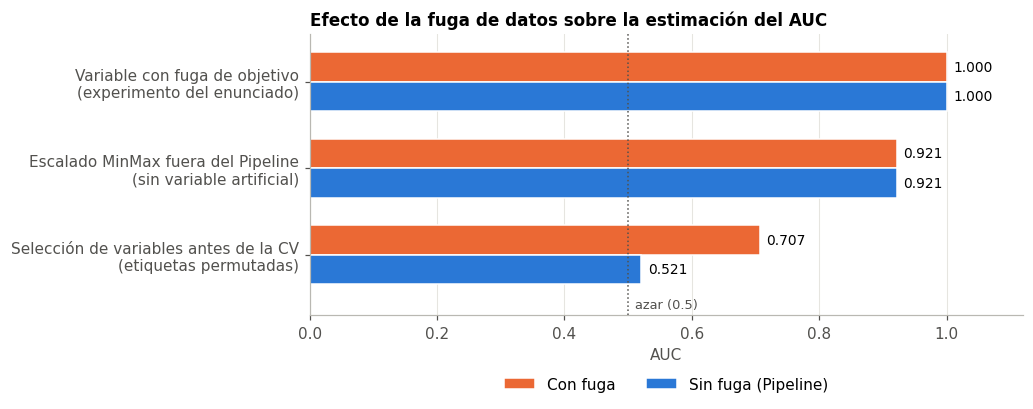

In [19]:
escenarios = pd.DataFrame({
    "Escenario": ["Variable con fuga de objetivo\n(experimento del enunciado)",
                  "Escalado MinMax fuera del Pipeline\n(sin variable artificial)",
                  "Selección de variables antes de la CV\n(etiquetas permutadas)"],
    "Con fuga": [auc_l, auc_l_limpio, auc_sel_fuga.mean()],
    "Sin fuga": [auc, auc_limpio, auc_sel_ok.mean()],
})
fig, ax = plt.subplots(figsize=(9.5, 3.9))
yy = np.arange(len(escenarios))[::-1]
h = 0.34
ax.barh(yy + h / 2, escenarios["Con fuga"], height=h, color=mu.COLORS["pos"], label="Con fuga", edgecolor="white")
ax.barh(yy - h / 2, escenarios["Sin fuga"], height=h, color=mu.COLORS["neg"], label="Sin fuga (Pipeline)", edgecolor="white")
for y0, a, b in zip(yy, escenarios["Con fuga"], escenarios["Sin fuga"]):
    ax.text(a + 0.01, y0 + h / 2, f"{a:.3f}", va="center", fontsize=9)
    ax.text(b + 0.01, y0 - h / 2, f"{b:.3f}", va="center", fontsize=9)
ax.axvline(0.5, color=mu.COLORS["ink2"], ls=":", lw=1)
ax.text(0.51, -0.62, "azar (0.5)", fontsize=8.5, color=mu.COLORS["ink2"])
ax.set_yticks(yy, escenarios["Escenario"])
ax.set_xlim(0, 1.12)
ax.set_xlabel("AUC")
ax.grid(axis="y", visible=False)
ax.set_ylim(-0.7, yy.max() + 0.55)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.17), ncol=2)
ax.set_title("Efecto de la fuga de datos sobre la estimación del AUC")
fig.tight_layout()
mu.save_figure(fig, "fig04_escenarios_fuga")
plt.show()

**Figura 4.** AUC estimado con y sin fuga en los tres escenarios analizados. La línea punteada marca el desempeño de un clasificador aleatorio.

El tercer escenario es el más elocuente. Con etiquetas permutadas no existe señal que aprender, y el procedimiento correcto lo reconoce: el AUC del `Pipeline` es 0.521 ± 0.035, indistinguible del azar. La selección previa a la validación cruzada, en cambio, reporta 0.707 ± 0.023, un desempeño aparentemente moderado que es enteramente ficticio: entre 2 000 variables de ruido, las 20 elegidas son justamente las que por azar se correlacionan con las etiquetas de toda la muestra, incluidas las de los pliegues de validación. Es el sesgo de selección descrito por Ambroise y McLachlan (2002) en genómica. Leídos en conjunto, los tres experimentos establecen la jerarquía de riesgos que guía el resto del proyecto: la fuga de objetivo se combate auditando variables, la fuga de preprocesamiento supervisado se combate con `Pipeline`, y la de preprocesamiento no supervisado, aunque aquí resulta despreciable, se elimina por la misma vía sin costo adicional.

## 6. Comparación de clasificadores sin fuga

### 6.1 Diseño experimental y funciones reutilizables

Siguiendo el enunciado, cada modelo se implementa dentro de un `Pipeline` cuyo primer paso es el preprocesador de la sección 4, se optimiza con `GridSearchCV` (validación cruzada estratificada de cinco pliegues, criterio de reajuste: AUC) y se evalúa una única vez en el conjunto de prueba. Se incluyen los nueve clasificadores estudiados en el curso hasta este capítulo: k-NN (cap. 2), regresión logística con penalización L1 o L2 (cap. 3, análogos de clasificación de Lasso y Ridge), Naive Bayes gaussiano (cap. 4), árbol de decisión, Random Forest, Gradient Boosting y XGBoost (cap. 5), SVM con núcleo RBF (cap. 6) y la combinación PCA + SVM (caps. 7 y 10.5). La lógica de entrenamiento y evaluación está encapsulada en funciones:

In [20]:
for funcion in (mu.train_pipeline, mu.evaluate_model, mu.run_benchmark):
    print(inspect.getsource(funcion))

def train_pipeline(X_train, y_train, model, param_grid, preprocessor=None,
                   cv=None, scoring="roc_auc", extra_steps=None) -> GridSearchCV:
    """Entrena ``preprocesamiento -> [pasos extra] -> clasificador`` con GridSearchCV.

    Toda transformación se ajusta dentro de cada pliegue, de modo que la
    información de validación nunca participa en el ajuste del preprocesador.
    """
    steps = [("prep", preprocessor if preprocessor is not None else build_preprocessor())]
    steps += list(extra_steps or [])
    steps.append(("clf", model))
    grid = GridSearchCV(
        Pipeline(steps), param_grid=param_grid, cv=cv or make_cv(),
        scoring={"roc_auc": "roc_auc", "accuracy": "accuracy"}, refit=scoring,
        n_jobs=-1, return_train_score=True,
    )
    grid.fit(X_train, y_train)
    return grid

def evaluate_model(estimator, X_test, y_test, threshold: float = 0.5) -> dict:
    """AUC y exactitud en el conjunto de prueba."""
    proba = estimator.predict_prob

In [21]:
modelos = mu.candidate_models()
espacio = pd.DataFrame([
    {"Modelo": nombre,
     "Hiperparámetros explorados": "; ".join(f"{k.split('__')[1]} ∈ {list(v) if len(v) <= 7 else f'{{{v[0]}, …, {v[-1]}}} ({len(v)} valores)'}"
                                             for k, v in spec["grid"].items()),
     "Combinaciones": int(np.prod([len(v) for v in spec["grid"].values()]))}
    for nombre, spec in modelos.items()
]).set_index("Modelo")
with pd.option_context("display.max_colwidth", None):
    display(espacio)
print(f"Total de ajustes (combinaciones × 5 pliegues): {espacio['Combinaciones'].sum() * 5:,}")

,Hiperparámetros explorados,Combinaciones
Modelo,,
SVC (RBF),"C ∈ [0.01, 0.1, 1, 10, 100]; gamma ∈ ['scale', 0.001, 0.01, 0.1, 1]",25
Regresión logística,"C ∈ [0.001, 0.01, 0.1, 1, 10, 100]; penalty ∈ ['l1', 'l2']",12
k-NN,"n_neighbors ∈ {3, …, 81} (40 valores); weights ∈ ['uniform', 'distance']; p ∈ [1, 2]",160
Naive Bayes gaussiano,"var_smoothing ∈ {1e-09, …, 10.0} (11 valores)",11
Árbol de decisión,"max_depth ∈ [2, 3, 4, 5, 6, 8, None]; min_samples_leaf ∈ [1, 5, 10, 20, 40]; criterion ∈ ['gini', 'entropy']",70
Random Forest,"max_depth ∈ [None, 4, 6, 8]; max_features ∈ ['sqrt', 0.5]; min_samples_leaf ∈ [1, 3, 5, 10]",32
Gradient Boosting,"n_estimators ∈ [50, 100, 200, 400]; learning_rate ∈ [0.01, 0.05, 0.1]; max_depth ∈ [1, 2, 3]; subsample ∈ [0.8, 1.0]",72
XGBoost,"n_estimators ∈ [100, 300, 600]; learning_rate ∈ [0.005, 0.01, 0.05, 0.1]; max_depth ∈ [2, 3, 4]; subsample ∈ [0.8, 1.0]; colsample_bytree ∈ [0.5, 0.7, 1.0]",216
PCA + SVC (RBF),"n_components ∈ [2, 4, 6, 8, 10, 12]; C ∈ [0.1, 1, 10]; gamma ∈ ['scale', 0.01, 0.1]",54


Total de ajustes (combinaciones × 5 pliegues): 3,260


**Tabla 2.** Espacio de búsqueda por modelo. Las rejillas se ampliaron hasta que ningún óptimo quedara en el borde explorado, salvo donde el borde es el valor natural (por ejemplo, `max_depth = None`).

### 6.2 Resultados y ranking comparativo

In [22]:
ranking, ajustados = mu.run_benchmark(modelos, X_train, y_train, X_test, y_test)
cols_fmt = {c: "{:.3f}" for c in ["AUC CV (media)", "AUC CV (d.e.)", "Accuracy CV", "AUC entrenamiento",
                                  "AUC prueba", "Accuracy prueba"]}
cols_fmt["Tiempo (s)"] = "{:.1f}"
(ranking.style.format(cols_fmt)
        .background_gradient(subset=["AUC CV (media)", "AUC prueba", "Accuracy prueba"], cmap="Oranges")
        .set_caption("Tabla 3. Ranking de clasificadores ordenado por AUC de validación cruzada"))

,Modelo,AUC CV (media),AUC CV (d.e.),Accuracy CV,AUC entrenamiento,AUC prueba,IC95% AUC prueba,Accuracy prueba,Combinaciones,Tiempo (s)
Ranking,,,,,,,,,,
1,XGBoost,0.939,0.024,0.866,0.986,0.935,"[0.895, 0.969]",0.897,216,53.1
2,Random Forest,0.934,0.026,0.861,0.975,0.930,"[0.887, 0.965]",0.880,32,39.5
3,Gradient Boosting,0.934,0.022,0.858,0.967,0.932,"[0.889, 0.967]",0.908,72,46.5
4,k-NN,0.930,0.032,0.860,1.000,0.939,"[0.899, 0.972]",0.908,160,25.0
5,PCA + SVC (RBF),0.929,0.035,0.862,0.938,0.934,"[0.894, 0.967]",0.875,54,11.2
6,Regresión logística,0.929,0.037,0.854,0.936,0.927,"[0.884, 0.963]",0.880,12,1.3
7,Naive Bayes gaussiano,0.928,0.035,0.862,0.930,0.927,"[0.884, 0.963]",0.886,11,1.1
8,SVC (RBF),0.928,0.036,0.860,0.941,0.935,"[0.894, 0.968]",0.880,25,14.7
9,Árbol de decisión,0.910,0.028,0.838,0.934,0.887,"[0.835, 0.930]",0.777,70,9.1


In [23]:
mejores = pd.DataFrame({n: g.best_params_ for n, g in ajustados.items()}).T
mejores.columns = [c.split("__")[1] for c in mejores.columns]
mejores.fillna("—")

,C,gamma,penalty,n_neighbors,p,weights,var_smoothing,criterion,max_depth,min_samples_leaf,max_features,learning_rate,n_estimators,subsample,colsample_bytree,n_components
SVC (RBF),1.0,0.1,—,—,—,—,—,—,—,—,—,—,—,—,—,—
Regresión logística,1,—,l2,—,—,—,—,—,—,—,—,—,—,—,—,—
k-NN,—,—,—,53,2,distance,—,—,—,—,—,—,—,—,—,—
Naive Bayes gaussiano,—,—,—,—,—,—,1.0,—,—,—,—,—,—,—,—,—
Árbol de decisión,—,—,—,—,—,—,—,gini,4,20,—,—,—,—,—,—
Random Forest,—,—,—,—,—,—,—,—,—,5,sqrt,—,—,—,—,—
Gradient Boosting,—,—,—,—,—,—,—,—,3.0,—,—,0.05,50.0,0.8,—,—
XGBoost,—,—,—,—,—,—,—,—,4.0,—,—,0.05,100.0,1.0,0.5,—
PCA + SVC (RBF),1.0,0.1,—,—,—,—,—,—,—,—,—,—,—,—,—,10.0


**Tabla 4.** Hiperparámetros óptimos seleccionados por `GridSearchCV`.

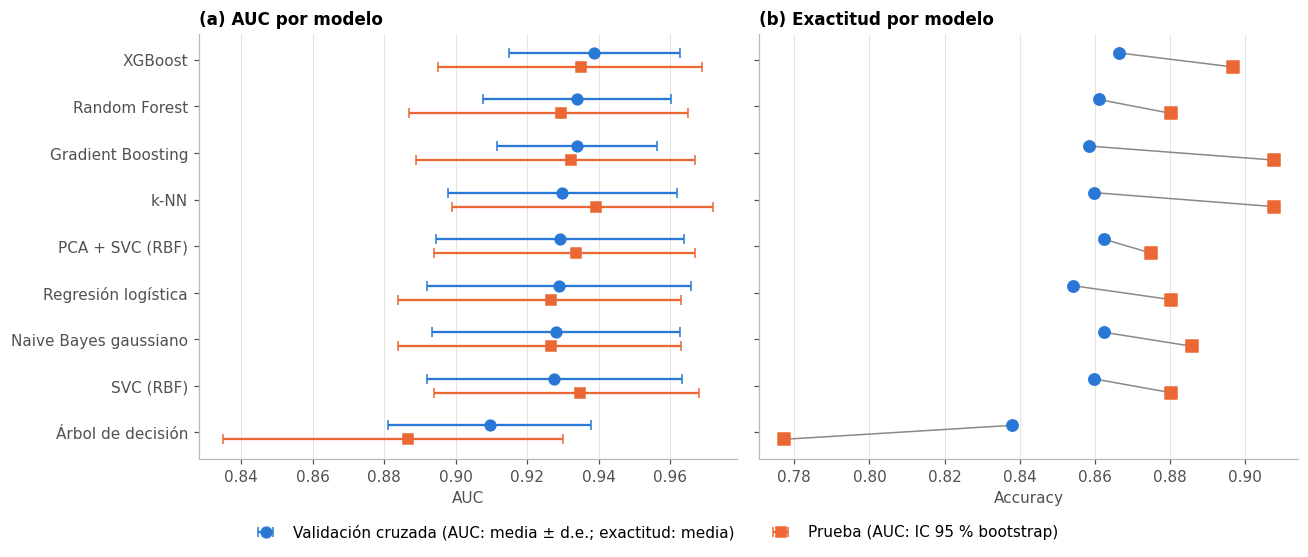

In [24]:
r = ranking.iloc[::-1].reset_index()
ic = r["IC95% AUC prueba"].str.strip("[]").str.split(", ", expand=True).astype(float)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharey=True)
yy = np.arange(len(r))
ax = axes[0]
ax.errorbar(r["AUC CV (media)"], yy + 0.15, xerr=r["AUC CV (d.e.)"], fmt="o", color=mu.COLORS["neg"],
            ms=7, capsize=3, lw=1.5, label="Validación cruzada (media ± d.e.)")
ax.errorbar(r["AUC prueba"], yy - 0.15, xerr=[r["AUC prueba"] - ic[0], ic[1] - r["AUC prueba"]], fmt="s",
            color=mu.COLORS["pos"], ms=7, capsize=3, lw=1.5, label="Prueba (IC 95 % bootstrap)")
ax.set_yticks(yy, r["Modelo"])
ax.set_xlabel("AUC")
ax.set_title("(a) AUC por modelo")
ax.grid(axis="y", visible=False)
ax = axes[1]
ax.scatter(r["Accuracy CV"], yy + 0.15, marker="o", s=55, color=mu.COLORS["neg"], label="Validación cruzada", zorder=3)
ax.scatter(r["Accuracy prueba"], yy - 0.15, marker="s", s=55, color=mu.COLORS["pos"], label="Prueba", zorder=3)
for y0, a, b in zip(yy, r["Accuracy CV"], r["Accuracy prueba"]):
    ax.plot([a, b], [y0 + 0.15, y0 - 0.15], color=mu.COLORS["muted"], lw=1, zorder=2)
ax.set_xlabel("Accuracy")
ax.set_title("(b) Exactitud por modelo")
ax.grid(axis="y", visible=False)
h1, l1 = axes[0].get_legend_handles_labels()
fig.legend(h1, ["Validación cruzada (AUC: media ± d.e.; exactitud: media)", "Prueba (AUC: IC 95 % bootstrap)"],
           loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.06))
fig.tight_layout()
mu.save_figure(fig, "fig05_ranking_modelos")
plt.show()

**Figura 5.** Desempeño de los nueve clasificadores optimizados, ordenados de arriba abajo por AUC de validación cruzada. (a) AUC en validación cruzada con su desviación estándar entre pliegues y AUC en prueba con intervalo de confianza bootstrap al 95 % (2 000 remuestreos). (b) Exactitud en validación cruzada y en prueba.

Ocho de los nueve clasificadores se concentran en una franja estrecha de AUC de validación cruzada, entre 0.928 (SVC) y 0.939 (XGBoost), con desviaciones entre pliegues de 0.022 a 0.037. El árbol de decisión individual queda claramente rezagado (AUC-CV de 0.910; AUC de prueba de 0.887 y exactitud de 0.777), resultado esperable de un estimador de alta varianza cuya configuración óptima (4 niveles, hojas de al menos 20 pacientes) limita su capacidad para representar fronteras suaves. XGBoost encabeza el ranking por AUC de validación cruzada y en prueba obtiene AUC = 0.935 con exactitud de 0.897; Gradient Boosting y k-NN logran las exactitudes de prueba más altas (0.908).

Dos precauciones gobiernan la lectura de la tabla. En primer lugar, los intervalos de confianza bootstrap del AUC de prueba tienen una amplitud cercana a 0.07 y se solapan casi por completo entre los ocho mejores modelos; con 184 pacientes de prueba, ninguna de esas diferencias es estadísticamente distinguible. Por ello el ranking se ordena por el AUC de validación cruzada, estimado sobre 734 pacientes y cinco particiones, y no por el desempeño en prueba, que se reserva como verificación final y no como criterio de selección: escoger el modelo con mejor AUC de prueba equivaldría a una forma sutil de fuga. En segundo lugar, la brecha entre el AUC de entrenamiento y el de validación orienta sobre el sobreajuste: es pequeña en los modelos lineales, Naive Bayes y SVC (alrededor de 0.01), moderada en los métodos de ensamble (0.03 a 0.05) y máxima en k-NN, cuyo AUC de entrenamiento de 1.000 es un artefacto de la ponderación por distancia (en entrenamiento cada punto es su propio vecino a distancia cero) y no una señal de memorización perjudicial, como confirma su AUC de prueba de 0.939.

### 6.3 Comparación con el SVC de referencia

El enunciado pide contrastar los clasificadores adicionales con el SVC. La tabla siguiente expresa cada modelo como diferencia respecto del SVC con núcleo RBF.

In [25]:
ref = ranking.set_index("Modelo").loc["SVC (RBF)"]
contraste = ranking.set_index("Modelo")[["AUC CV (media)", "AUC prueba", "Accuracy prueba"]].sub(
    ref[["AUC CV (media)", "AUC prueba", "Accuracy prueba"]].astype(float))
contraste.columns = ["Δ AUC CV vs. SVC", "Δ AUC prueba vs. SVC", "Δ Accuracy prueba vs. SVC"]
contraste.style.format("{:+.3f}").set_caption("Tabla 5. Diferencias respecto del SVC (RBF)")

,Δ AUC CV vs. SVC,Δ AUC prueba vs. SVC,Δ Accuracy prueba vs. SVC
Modelo,,,
XGBoost,+0.011,+0.000,+0.016
Random Forest,+0.007,-0.005,+0.000
Gradient Boosting,+0.006,-0.003,+0.027
k-NN,+0.002,+0.005,+0.027
PCA + SVC (RBF),+0.002,-0.001,-0.005
Regresión logística,+0.001,-0.008,+0.000
Naive Bayes gaussiano,+0.001,-0.008,+0.005
SVC (RBF),+0.000,+0.000,+0.000
Árbol de decisión,-0.018,-0.048,-0.103


Frente al SVC con núcleo RBF, todos los modelos salvo el árbol de decisión mejoran el AUC de validación cruzada, pero por márgenes de entre +0.001 (regresión logística y Naive Bayes) y +0.011 (XGBoost), con Random Forest (+0.007) y Gradient Boosting (+0.006) en posición intermedia; en ningún caso la ganancia supera la desviación estándar entre pliegues. En el conjunto de prueba las diferencias de AUC respecto del SVC son de pocas milésimas para los ocho mejores modelos, mientras que las de exactitud alcanzan casi tres puntos porcentuales, porque esta métrica depende del umbral de 0.5 y es mucho más sensible que el AUC a los pocos pacientes cercanos a la frontera de decisión. La conclusión práctica es que, una vez resuelto el preprocesamiento sin fuga, la representación de los datos condiciona el desempeño más que la elección del algoritmo. Los métodos de *boosting* ofrecen la mejor estimación central y serán candidatos naturales en la Etapa 2, donde la selección del modelo final se hará con una búsqueda conjunta sobre familias de modelos dentro de un único `GridSearchCV`.

## 7. Conclusiones

El análisis exploratorio mostró que el conjunto *Heart Failure Prediction* no tiene faltantes explícitos, pero sí 172 valores de colesterol codificados como cero, cuyo patrón de ausencia se asocia con una prevalencia de enfermedad del 88.4 %. Esa observación motivó un preprocesamiento que imputa con la mediana de entrenamiento y conserva un indicador de ausencia, encapsulado junto con el escalado MinMax y la codificación one-hot en un `ColumnTransformer`.

La demostración de fuga de datos permitió separar tres mecanismos. La variable artificial del enunciado produce un AUC de 1.000 incluso dentro de un `Pipeline`, lo que prueba que la encapsulación no sustituye a la auditoría de variables; una regla de AUC univariado superior a 0.95 la identifica sin ambigüedad. El preprocesamiento no supervisado ajustado con todos los datos introdujo, en 50 particiones, un sesgo medio inferior a 10⁻⁴ en el AUC, despreciable en este conjunto. La selección de variables previa a la validación cruzada, por el contrario, fabricó un AUC de 0.707 sobre etiquetas sin señal, frente al 0.521 del flujo correcto.

En el flujo sin fuga, los nueve clasificadores del curso, cada uno con su `Pipeline` y su `GridSearchCV`, alcanzaron AUC de validación cruzada entre 0.910 y 0.939. XGBoost encabeza el ranking (AUC-CV de 0.939, AUC de prueba de 0.935 y exactitud de prueba de 0.897), aunque sus ventajas sobre los siete modelos siguientes son menores que la incertidumbre muestral. El cuaderno `2_model_pipeline_cv.ipynb` retoma estos resultados para seleccionar el modelo final, evaluarlo con matriz de confusión y curva ROC, y exportarlo para su despliegue con FastAPI y Docker.

## 8. Referencias

- fedesoriano (2021). *Heart Failure Prediction Dataset*. Kaggle. https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction
- Detrano, R., Janosi, A., Steinbrunn, W., Pfisterer, M., Schmid, J., Sandhu, S., Guppy, K., Lee, S. y Froelicher, V. (1989). International application of a new probability algorithm for the diagnosis of coronary artery disease. *American Journal of Cardiology*, 64(5), 304–310.
- Kaufman, S., Rosset, S., Perlich, C. y Stitelman, O. (2012). Leakage in data mining: Formulation, detection, and avoidance. *ACM Transactions on Knowledge Discovery from Data*, 6(4), 1–21.
- Müller, A. C. y Guido, S. (2016). *Introduction to Machine Learning with Python*. O'Reilly Media. Capítulo 6: Algorithm Chains and Pipelines.
- Pedregosa, F. et al. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research*, 12, 2825–2830.
- Rubio, L. (2023). *Machine Learning*, capítulo 10: Pipelines. https://lihkir.github.io/MachineLearning/chains_pipelines.html
- Ambroise, C. y McLachlan, G. J. (2002). Selection bias in gene extraction on the basis of microarray gene-expression data. *PNAS*, 99(10), 6562–6566.

# Parte II. Modelado con validación segura, evaluación y exportación del modelo

**Predicción de falla cardíaca con *pipelines* de aprendizaje automático** · Etapa 2 del proyecto integrador

Manuel Meza · Kevin Clemente — Machine Learning (maestría), Prof. Dr. Lihki Rubio — Octubre de 2026

---

**Resumen.** Este cuaderno desarrolla la Etapa 2 del proyecto integrador. Los datos se dividen en entrenamiento y prueba antes de cualquier transformación; el preprocesamiento, la reducción de dimensionalidad opcional y el clasificador se encadenan en un único `Pipeline`, y un `GridSearchCV` con validación cruzada estratificada explora conjuntamente nueve familias de modelos y sus hiperparámetros. La búsqueda, con 652 configuraciones y 3 260 ajustes, selecciona un XGBoost (100 árboles de profundidad 4, tasa de aprendizaje 0.05) con AUC de validación cruzada de 0.939 ± 0.024. En el conjunto de prueba, evaluado una única vez, el modelo alcanza AUC = 0.935 (IC 95 %: 0.895–0.969), exactitud de 0.897, sensibilidad de 0.912 y especificidad de 0.878. La curva de aprendizaje y la concordancia entre validación cruzada y prueba descartan un sobreajuste perjudicial. El pipeline completo se exporta como `model.joblib` para su despliegue.

**Palabras clave:** `Pipeline`, `GridSearchCV`, validación cruzada estratificada, matriz de confusión, curva ROC, AUC.

## Contenido

1. Introducción
2. Datos y partición previa a toda transformación
3. Pipeline y búsqueda conjunta de modelo e hiperparámetros
4. Evaluación en el conjunto de prueba: matriz de confusión, curva ROC y AUC
5. Verificación de ausencia de sobreajuste
6. Interpretación del modelo
7. Exportación del modelo para despliegue
8. Conclusiones
9. Referencias

## 1. Introducción

La Etapa 1 (`1_model_leakage_demo.ipynb`) estableció el preprocesamiento del proyecto y comparó nueve clasificadores optimizados de forma independiente. Aquí el objetivo es producir el modelo que se pondrá en producción, con tres exigencias del enunciado: (i) la partición de los datos debe preceder al escalado, (ii) la optimización debe realizarse con `Pipeline` y `GridSearchCV`, y (iii) la evaluación debe reportar matriz de confusión, curva ROC y AUC.

La selección del modelo se plantea como un único problema de búsqueda, siguiendo la estrategia de la sección 10.9 del curso: el clasificador final y el paso de reducción de dimensionalidad son a su vez parámetros del `Pipeline`, de modo que `GridSearchCV` compara familias de modelos y configuraciones bajo exactamente los mismos pliegues de validación. El conjunto de prueba no interviene en ninguna decisión; se usa una sola vez, al final, para estimar el desempeño de generalización.

In [1]:
import json
import platform
import shutil
import warnings
from datetime import datetime, timezone

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import xgboost
from IPython.display import display
from sklearn.decomposition import PCA
from sklearn.inspection import permutation_importance
from sklearn.metrics import (ConfusionMatrixDisplay, auc, classification_report, confusion_matrix,
                             roc_auc_score, roc_curve)
from sklearn.model_selection import GridSearchCV, cross_val_predict, learning_curve
from sklearn.pipeline import Pipeline

import ml_utils as mu

warnings.filterwarnings("ignore")
mu.set_plot_style()
pd.set_option("display.precision", 3)
print(f"Python {platform.python_version()} · scikit-learn {sklearn.__version__} · xgboost {xgboost.__version__}")

Python 3.10.21 · scikit-learn 1.6.1 · xgboost 3.0.5


## 2. Datos y partición previa a toda transformación

La partición se realiza sobre los datos crudos, con 20 % para prueba, estratificación por clase y semilla fija. A partir de este punto el conjunto de prueba queda «sellado».

In [2]:
df = mu.load_data()
X_train, X_test, y_train, y_test = mu.split_data(df)
particion = pd.DataFrame({
    "Pacientes": [len(y_train), len(y_test)],
    "Positivos": [int(y_train.sum()), int(y_test.sum())],
    "Prevalencia": [y_train.mean(), y_test.mean()],
}, index=["Entrenamiento", "Prueba"])
particion

,Pacientes,Positivos,Prevalencia
Entrenamiento,734,406,0.553
Prueba,184,102,0.554


Para hacer verificable que el escalado se aprende solo del entrenamiento, se ajusta el preprocesador con `X_train` y se inspeccionan los rangos resultantes. Con `MinMaxScaler`, las variables continuas de entrenamiento quedan exactamente en [0, 1]; en prueba, cualquier valor fuera de ese intervalo evidencia que los parámetros del escalador no incorporaron información de ese subconjunto.

In [3]:
prep = mu.build_preprocessor().fit(X_train)
cols = prep.get_feature_names_out()
Zt = pd.DataFrame(prep.transform(X_train), columns=cols)
Zs = pd.DataFrame(prep.transform(X_test), columns=cols)
continuas = ["zero_missing__RestingBP", "zero_missing__Cholesterol", "num__Age", "num__MaxHR", "num__Oldpeak"]
rangos = pd.DataFrame({
    "Mín. entrenamiento": Zt[continuas].min(), "Máx. entrenamiento": Zt[continuas].max(),
    "Mín. prueba": Zs[continuas].min(), "Máx. prueba": Zs[continuas].max(),
})
rangos

,Mín. entrenamiento,Máx. entrenamiento,Mín. prueba,Máx. prueba
zero_missing__RestingBP,0.0,1.0,-0.111,0.926
zero_missing__Cholesterol,0.0,1.0,0.048,0.836
num__Age,0.0,1.0,-0.021,0.958
num__MaxHR,0.0,1.0,0.141,0.951
num__Oldpeak,0.0,1.0,0.305,1.073


En entrenamiento las cinco variables continuas ocupan exactamente el intervalo [0, 1], mientras que en prueba aparecen valores fuera de él: −0.111 en `RestingBP` (el paciente con presión de 0 mm Hg queda imputado con la mediana de entrenamiento; el valor negativo corresponde a otro paciente con presión inferior al mínimo de entrenamiento), −0.021 en `Age` y 1.073 en `Oldpeak`. Esos desbordes son la evidencia empírica de que el mínimo y el máximo se aprendieron sin ver la prueba, que es justamente lo que exige la validación honesta. En producción ocurrirá lo mismo con pacientes nuevos, y ninguno de los modelos considerados requiere que la entrada esté acotada.

## 3. Pipeline y búsqueda conjunta de modelo e hiperparámetros

### 3.1 Arquitectura del pipeline

El `Pipeline` tiene tres pasos: `prep`, el `ColumnTransformer` de la Etapa 1 (imputación con indicador de ausencia, escalado MinMax y one-hot); `reduce`, que por defecto es `"passthrough"` y solo toma el valor `PCA` en la rama PCA + SVC; y `clf`, el clasificador. Como todos los pasos se reajustan dentro de cada pliegue, los datos de validación de un pliegue nunca participan en la imputación, el escalado, la codificación ni la proyección PCA.

In [4]:
pipe = Pipeline([
    ("prep", mu.build_preprocessor()),
    ("reduce", "passthrough"),
    ("clf", "passthrough"),
])
pipe

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('zero_missing',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(add_indicator=True,
                                                                                 missing_values=0,
                                                                                 strategy='median')),
                                                                  ('scaler',
                                                                   MinMaxScaler())]),
                                                  ['RestingBP', 'Cholesterol']),
                                                 ('num',
                                                  Pipeline(steps=[('scaler',
                                                                   MinMaxScaler())]),
                                                  ['Age', 'MaxHR'

### 3.2 Rejilla de búsqueda

La rejilla se construye a partir de `mu.candidate_models()`, la misma definición usada en la Etapa 1: cada familia aporta un diccionario en el que el paso `clf` toma el estimador correspondiente y sus hiperparámetros se nombran con la convención `paso__parámetro`. La rama PCA + SVC fija además `reduce = PCA` y explora el número de componentes.

In [5]:
def construir_rejilla(candidatos):
    rejilla = []
    for nombre, spec in candidatos.items():
        bloque = {"clf": [spec["model"]], **spec["grid"]}
        if spec.get("extra_steps"):
            for paso, objeto in spec["extra_steps"]:
                bloque = {k.replace(f"{paso}__", "reduce__"): v for k, v in bloque.items()}
                bloque["reduce"] = [objeto]
        rejilla.append(bloque)
    return rejilla


candidatos = mu.candidate_models()
param_grid = construir_rejilla(candidatos)
n_comb = sum(int(np.prod([len(v) for v in b.values()])) for b in param_grid)
print(f"Familias: {len(param_grid)} · combinaciones: {n_comb} · ajustes con CV de 5 pliegues: {n_comb * 5:,}")

Familias: 9 · combinaciones: 652 · ajustes con CV de 5 pliegues: 3,260


In [6]:
cv = mu.make_cv()
grid = GridSearchCV(pipe, param_grid=param_grid, cv=cv,
                    scoring={"roc_auc": "roc_auc", "accuracy": "accuracy"}, refit="roc_auc",
                    n_jobs=-1, return_train_score=True)
grid.fit(X_train, y_train)
print(f"Mejor AUC de validación cruzada: {grid.best_score_:.4f}")
print(f"Mejor familia: {type(grid.best_params_['clf']).__name__}")
for k, v in grid.best_params_.items():
    if k != "clf":
        print(f"  {k} = {v}")

Mejor AUC de validación cruzada: 0.9388
Mejor familia: XGBClassifier
  clf__colsample_bytree = 0.5
  clf__learning_rate = 0.05
  clf__max_depth = 4
  clf__n_estimators = 100
  clf__subsample = 1.0


### 3.3 Resultados de la validación cruzada

La tabla siguiente reporta, para cada familia, su mejor configuración dentro de la búsqueda conjunta. Como todas comparten pliegues, las diferencias son atribuibles al modelo y no a la partición.

In [7]:
res = pd.DataFrame(grid.cv_results_)
nombre_por_clase = {}
for nombre, spec in candidatos.items():
    clave = type(spec["model"]).__name__ + ("+PCA" if spec.get("extra_steps") else "")
    nombre_por_clase[clave] = nombre
res["Familia"] = [nombre_por_clase[type(p["clf"]).__name__ + ("+PCA" if isinstance(p.get("reduce"), PCA) else "")]
                  for p in res["params"]]
mejor_por_familia = (res.sort_values("mean_test_roc_auc", ascending=False).groupby("Familia").head(1)
                       .set_index("Familia")[["mean_test_roc_auc", "std_test_roc_auc", "mean_test_accuracy",
                                              "mean_train_roc_auc", "rank_test_roc_auc"]])
mejor_por_familia.columns = ["AUC CV", "d.e.", "Accuracy CV", "AUC entrenamiento", "Rango global"]
mejor_por_familia["Brecha entrenamiento − CV"] = mejor_por_familia["AUC entrenamiento"] - mejor_por_familia["AUC CV"]
mejor_por_familia.style.format("{:.3f}", subset=["AUC CV", "d.e.", "Accuracy CV", "AUC entrenamiento",
                                                 "Brecha entrenamiento − CV"]).set_caption(
    "Tabla 1. Mejor configuración de cada familia en la búsqueda conjunta")

,AUC CV,d.e.,Accuracy CV,AUC entrenamiento,Rango global,Brecha entrenamiento − CV
Familia,,,,,,
XGBoost,0.939,0.024,0.866,0.986,1,0.047
Random Forest,0.934,0.026,0.861,0.975,36,0.041
Gradient Boosting,0.934,0.022,0.858,0.967,40,0.034
k-NN,0.930,0.032,0.860,1.000,145,0.070
PCA + SVC (RBF),0.929,0.035,0.862,0.938,167,0.009
Regresión logística,0.929,0.037,0.854,0.936,185,0.007
Naive Bayes gaussiano,0.928,0.035,0.862,0.930,227,0.002
SVC (RBF),0.928,0.036,0.860,0.941,258,0.013
Árbol de decisión,0.910,0.028,0.838,0.934,549,0.024


In [8]:
top = res.sort_values("rank_test_roc_auc").head(10)
top_tabla = pd.DataFrame({
    "Familia": top["Familia"],
    "AUC CV": top["mean_test_roc_auc"],
    "d.e.": top["std_test_roc_auc"],
    "Hiperparámetros": [", ".join(f"{k.split('__')[-1]}={v}" for k, v in p.items() if k not in ("clf", "reduce"))
                        for p in top["params"]],
}).reset_index(drop=True)
top_tabla.index += 1
with pd.option_context("display.max_colwidth", None):
    display(top_tabla.style.format({"AUC CV": "{:.4f}", "d.e.": "{:.4f}"}).set_caption(
        "Tabla 2. Las diez mejores configuraciones de toda la búsqueda"))

,Familia,AUC CV,d.e.,Hiperparámetros
1,XGBoost,0.9388,0.0240,"colsample_bytree=0.5, learning_rate=0.05, max_depth=4, n_estimators=100, subsample=1.0"
2,XGBoost,0.9374,0.0264,"colsample_bytree=0.5, learning_rate=0.05, max_depth=4, n_estimators=100, subsample=0.8"
3,XGBoost,0.9373,0.0261,"colsample_bytree=0.5, learning_rate=0.005, max_depth=3, n_estimators=600, subsample=1.0"
4,XGBoost,0.9371,0.0272,"colsample_bytree=0.5, learning_rate=0.01, max_depth=4, n_estimators=600, subsample=1.0"
5,XGBoost,0.9368,0.0259,"colsample_bytree=0.5, learning_rate=0.01, max_depth=3, n_estimators=300, subsample=1.0"
6,XGBoost,0.9366,0.0261,"colsample_bytree=0.5, learning_rate=0.01, max_depth=4, n_estimators=300, subsample=1.0"
7,XGBoost,0.9365,0.0264,"colsample_bytree=0.5, learning_rate=0.005, max_depth=4, n_estimators=600, subsample=1.0"
8,XGBoost,0.9363,0.0286,"colsample_bytree=0.5, learning_rate=0.01, max_depth=3, n_estimators=600, subsample=0.8"
9,XGBoost,0.9363,0.0237,"colsample_bytree=0.7, learning_rate=0.01, max_depth=3, n_estimators=300, subsample=1.0"
10,XGBoost,0.9362,0.0287,"colsample_bytree=0.5, learning_rate=0.01, max_depth=3, n_estimators=600, subsample=1.0"


La búsqueda conjunta reproduce el ordenamiento de la Etapa 1, como era de esperar al compartir rejillas, semilla y pliegues, pero ahora la comparación se hace en un único experimento. XGBoost obtiene el mejor AUC de validación cruzada (0.9388 ± 0.0240), seguido de Random Forest y Gradient Boosting (0.934). Las diez mejores configuraciones de toda la búsqueda son variantes de XGBoost con AUC entre 0.9362 y 0.9388, lo que indica una meseta amplia del desempeño en el espacio de hiperparámetros y no un óptimo puntual frágil: profundidades de 3 o 4, submuestreo de columnas de 0.5 y combinaciones equivalentes de tasa de aprendizaje y número de árboles (0.05 con 100 árboles, 0.01 con 300 a 600). Esa estabilidad es deseable en un modelo destinado a producción.

La brecha entre el AUC de entrenamiento y el de validación del modelo elegido (0.047) es mayor que la de los modelos lineales (menos de 0.01), lo que se examina en la sección 5. Dado que las diferencias entre familias son inferiores a una desviación estándar, la regla de un error estándar habría permitido optar por un modelo más simple como la regresión logística; se mantiene XGBoost porque el criterio fijado de antemano es el AUC de validación cruzada y porque la sección 5 muestra que su mayor flexibilidad no se traduce en pérdida de generalización.

## 4. Evaluación en el conjunto de prueba

El estimador final es `grid.best_estimator_`, reajustado por `GridSearchCV` sobre todo el conjunto de entrenamiento con la mejor configuración. Se evalúa una sola vez sobre los 184 pacientes de prueba con el umbral de decisión de 0.5 que usará la API.

In [9]:
modelo = grid.best_estimator_
proba_test = modelo.predict_proba(X_test)[:, 1]
pred_test = (proba_test >= 0.5).astype(int)
auc_test = roc_auc_score(y_test, proba_test)
ic_lo, ic_hi = mu.bootstrap_auc_ci(y_test, proba_test)
tn, fp, fn, tp = confusion_matrix(y_test, pred_test).ravel()
metricas = pd.Series({
    "AUC": auc_test,
    "IC 95 % AUC (bootstrap) — inferior": ic_lo,
    "IC 95 % AUC (bootstrap) — superior": ic_hi,
    "Accuracy": (tp + tn) / len(y_test),
    "Sensibilidad (recall clase 1)": tp / (tp + fn),
    "Especificidad (recall clase 0)": tn / (tn + fp),
    "Valor predictivo positivo": tp / (tp + fp),
    "Valor predictivo negativo": tn / (tn + fn),
    "F1 (clase 1)": 2 * tp / (2 * tp + fp + fn),
}, name="Prueba").to_frame()
metricas

,Prueba
AUC,0.935
IC 95 % AUC (bootstrap) — inferior,0.895
IC 95 % AUC (bootstrap) — superior,0.969
Accuracy,0.897
Sensibilidad (recall clase 1),0.912
Especificidad (recall clase 0),0.878
Valor predictivo positivo,0.903
Valor predictivo negativo,0.889
F1 (clase 1),0.907


In [10]:
print(classification_report(y_test, pred_test, target_names=["Sin enfermedad (0)", "Con enfermedad (1)"], digits=3))

                    precision    recall  f1-score   support

Sin enfermedad (0)      0.889     0.878     0.883        82
Con enfermedad (1)      0.903     0.912     0.907       102

          accuracy                          0.897       184
         macro avg      0.896     0.895     0.895       184
      weighted avg      0.897     0.897     0.897       184



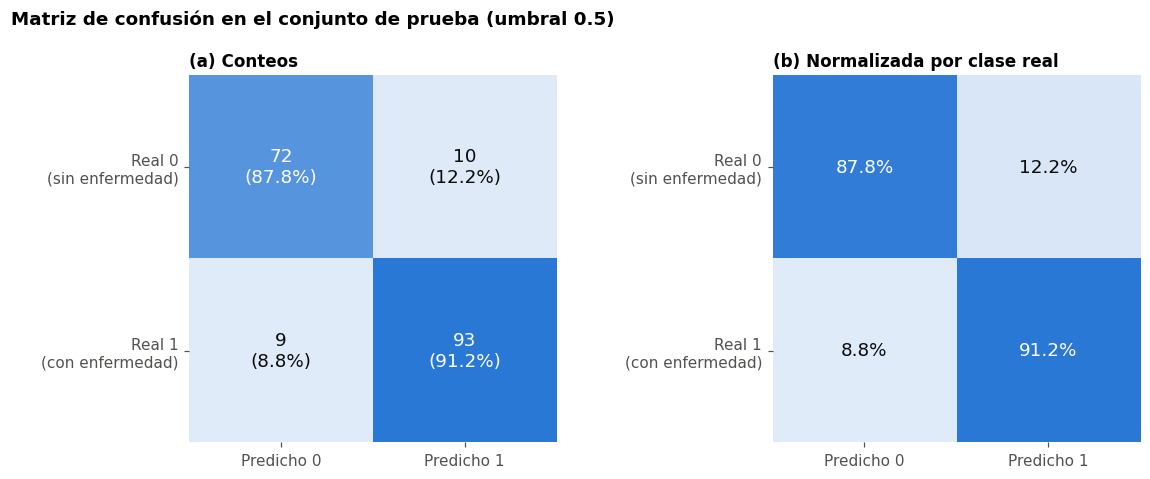

In [11]:
from matplotlib.colors import LinearSegmentedColormap
cmap_seq = LinearSegmentedColormap.from_list("seq", ["#f4f8fd", mu.COLORS["neg"]])
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
cm = confusion_matrix(y_test, pred_test)
cm_norm = cm / cm.sum(axis=1, keepdims=True)
for ax, matriz, titulo, fmt in [(axes[0], cm, "(a) Conteos", "d"), (axes[1], cm_norm, "(b) Normalizada por clase real", ".1%")]:
    im = ax.imshow(matriz, cmap=cmap_seq, vmin=0)
    for i in range(2):
        for j in range(2):
            valor = format(matriz[i, j], fmt)
            if fmt == "d":
                valor += f"\n({cm_norm[i, j]:.1%})"
            ax.text(j, i, valor, ha="center", va="center", fontsize=12,
                    color="white" if matriz[i, j] > matriz.max() * 0.6 else mu.COLORS["ink"])
    ax.set_xticks([0, 1], ["Predicho 0", "Predicho 1"])
    ax.set_yticks([0, 1], ["Real 0\n(sin enfermedad)", "Real 1\n(con enfermedad)"])
    ax.grid(False)
    for s in ax.spines.values():
        s.set_visible(False)
    ax.set_title(titulo)
fig.suptitle("Matriz de confusión en el conjunto de prueba (umbral 0.5)", x=0.01, ha="left", fontweight="bold")
fig.tight_layout()
mu.save_figure(fig, "fig06_matriz_confusion")
plt.show()

**Figura 1.** Matriz de confusión del modelo final sobre el conjunto de prueba. (a) Conteos absolutos con el porcentaje por clase real. (b) Proporciones normalizadas por fila: la diagonal corresponde a especificidad (fila 0) y sensibilidad (fila 1).

De los 102 pacientes enfermos del conjunto de prueba, el modelo identifica 93 (sensibilidad de 91.2 %) y deja 9 falsos negativos; de los 82 sanos, clasifica correctamente 72 (especificidad de 87.8 %) y genera 10 falsos positivos. Los errores están, por tanto, equilibrados entre ambas clases, con un valor predictivo positivo de 0.903 y negativo de 0.889. La exactitud global de 0.897 supera holgadamente la tasa de la clase mayoritaria (0.554), referencia mínima que cualquier clasificador debe batir.

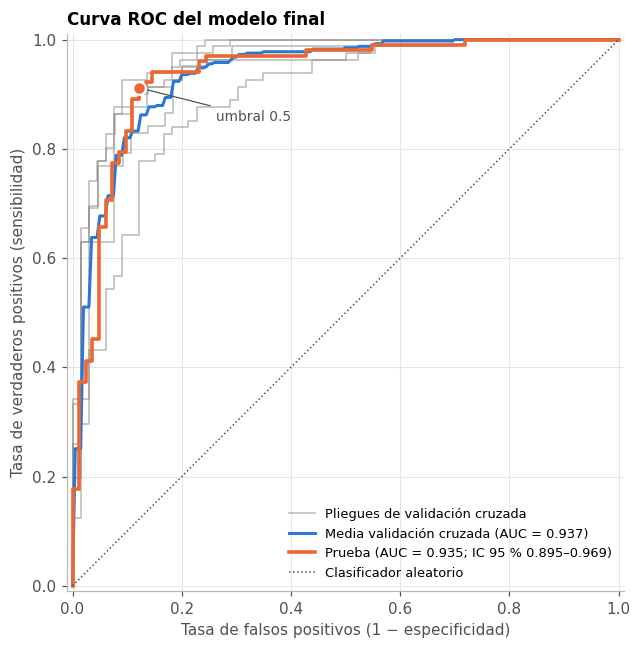

In [12]:
# Curvas ROC de validación cruzada (fuera de pliegue) para cuantificar su variabilidad
fig, ax = plt.subplots(figsize=(6.4, 6))
fpr_grid = np.linspace(0, 1, 201)
tprs = []
for k, (i_tr, i_va) in enumerate(cv.split(X_train, y_train)):
    m = sklearn.base.clone(modelo).fit(X_train.iloc[i_tr], y_train.iloc[i_tr])
    p = m.predict_proba(X_train.iloc[i_va])[:, 1]
    f, t, _ = roc_curve(y_train.iloc[i_va], p)
    tprs.append(np.interp(fpr_grid, f, t))
    tprs[-1][0] = 0.0
    ax.plot(f, t, color=mu.COLORS["muted"], lw=1, alpha=0.6, label="Pliegues de validación cruzada" if k == 0 else None)
tpr_media = np.mean(tprs, axis=0)
tpr_media[-1] = 1.0
ax.plot(fpr_grid, tpr_media, color=mu.COLORS["neg"], lw=2,
        label=f"Media validación cruzada (AUC = {auc(fpr_grid, tpr_media):.3f})")
fpr, tpr, umbrales = roc_curve(y_test, proba_test)
ax.plot(fpr, tpr, color=mu.COLORS["pos"], lw=2.4,
        label=f"Prueba (AUC = {auc_test:.3f}; IC 95 % {ic_lo:.3f}–{ic_hi:.3f})")
i05 = np.argmin(np.abs(umbrales - 0.5))
ax.scatter(fpr[i05], tpr[i05], s=70, color=mu.COLORS["pos"], edgecolor="white", linewidth=1.5, zorder=5)
ax.annotate("umbral 0.5", (fpr[i05], tpr[i05]), xytext=(fpr[i05] + 0.14, tpr[i05] - 0.06),
            arrowprops=dict(arrowstyle="-", color=mu.COLORS["ink2"], lw=0.8), fontsize=9, color=mu.COLORS["ink2"])
ax.plot([0, 1], [0, 1], ls=":", color=mu.COLORS["ink2"], lw=1, label="Clasificador aleatorio")
ax.set_xlabel("Tasa de falsos positivos (1 − especificidad)")
ax.set_ylabel("Tasa de verdaderos positivos (sensibilidad)")
ax.set_xlim(-0.01, 1.01)
ax.set_ylim(-0.01, 1.01)
ax.set_aspect("equal")
ax.legend(loc="lower right", fontsize=8.5)
ax.set_title("Curva ROC del modelo final")
fig.tight_layout()
mu.save_figure(fig, "fig07_curva_roc")
plt.show()

**Figura 2.** Curva ROC del modelo final. En gris, las curvas de los cinco pliegues de validación cruzada (cada una ajustada sin ver su pliegue); en azul, su promedio vertical; en naranja, la curva sobre el conjunto de prueba, con el punto de operación correspondiente al umbral 0.5.

La curva de prueba (AUC = 0.935) se superpone a la curva media de validación cruzada (AUC = 0.937, promedio vertical de los cinco pliegues) y queda dentro de la dispersión de las curvas individuales. Esa coincidencia entre una estimación interna, obtenida solo con entrenamiento, y una externa, obtenida con datos nunca vistos, es el principal argumento a favor de que el procedimiento de validación no está sesgado. La curva asciende de forma pronunciada: con una tasa de falsos positivos de 0.122 el modelo ya recupera el 91 % de los enfermos, y por encima de 0.25 la sensibilidad supera 0.96.

### 4.1 Sensibilidad al umbral de decisión

La API del enunciado clasifica con umbral 0.5. En un contexto de tamizaje clínico, sin embargo, el costo de un falso negativo suele superar al de un falso positivo, por lo que conviene documentar cómo cambian sensibilidad y especificidad con el umbral. Para no contaminar la prueba, el análisis se hace con predicciones **fuera de pliegue** del conjunto de entrenamiento (`cross_val_predict`), y la prueba solo se usa para verificar.

In [13]:
proba_oof = cross_val_predict(modelo, X_train, y_train, cv=cv, method="predict_proba")[:, 1]
filas = []
for u in [0.3, 0.4, 0.5, 0.6, 0.7]:
    for nombre, yy, pp in [("Fuera de pliegue (entrenamiento)", y_train, proba_oof), ("Prueba", y_test, proba_test)]:
        tn_, fp_, fn_, tp_ = confusion_matrix(yy, (pp >= u).astype(int)).ravel()
        filas.append({"Umbral": u, "Conjunto": nombre, "Sensibilidad": tp_ / (tp_ + fn_),
                      "Especificidad": tn_ / (tn_ + fp_), "Accuracy": (tp_ + tn_) / len(yy),
                      "Falsos negativos": fn_})
orden = [(c, m) for c in ["Fuera de pliegue (entrenamiento)", "Prueba"]
         for m in ["Sensibilidad", "Especificidad", "Accuracy", "Falsos negativos"]]
umbral_tabla = pd.DataFrame(filas).pivot(index="Umbral", columns="Conjunto").swaplevel(axis=1)[orden]
(umbral_tabla.style.format("{:.3f}").format("{:.0f}", subset=[c for c in orden if c[1] == "Falsos negativos"])
    .format_index("{:.1f}", axis=0).set_caption("Tabla 3. Métricas según el umbral de decisión"))

Las predicciones fuera de pliegue reproducen el comportamiento observado en prueba, lo que permite decidir el umbral sin consultar esta última. Con el umbral de 0.5 de la API se obtiene, fuera de pliegue, una sensibilidad de 0.894 y una especificidad de 0.832. Bajar el umbral a 0.4 eleva la sensibilidad a 0.936 y reduce los falsos negativos de 43 a 26 en entrenamiento (de 9 a 6 en prueba), a cambio de una especificidad de 0.784; la exactitud apenas varía (0.866 frente a 0.868). En un sistema de tamizaje, donde un falso negativo implica un paciente en riesgo sin seguimiento, ese intercambio suele ser preferible. Para conservar la fidelidad con el enunciado, la API mantiene el umbral de 0.5, pero el umbral queda registrado en los metadatos del modelo para que pueda ajustarse con criterio clínico sin reentrenar.

## 5. Verificación de ausencia de sobreajuste

Se aplican dos pruebas complementarias, siguiendo la sección 10.18 del curso: la comparación directa de métricas entre entrenamiento, validación cruzada y prueba, y la curva de aprendizaje.

In [14]:
proba_train = modelo.predict_proba(X_train)[:, 1]
comparacion = pd.DataFrame({
    "AUC": [roc_auc_score(y_train, proba_train), grid.best_score_, auc_test],
    "Accuracy": [((proba_train >= 0.5) == y_train).mean(),
                 grid.cv_results_["mean_test_accuracy"][grid.best_index_],
                 (pred_test == y_test).mean()],
}, index=["Entrenamiento (reajuste completo)", "Validación cruzada (5 pliegues)", "Prueba"])
comparacion

,AUC,Accuracy
Entrenamiento (reajuste completo),0.984,0.936
Validación cruzada (5 pliegues),0.939,0.866
Prueba,0.935,0.897


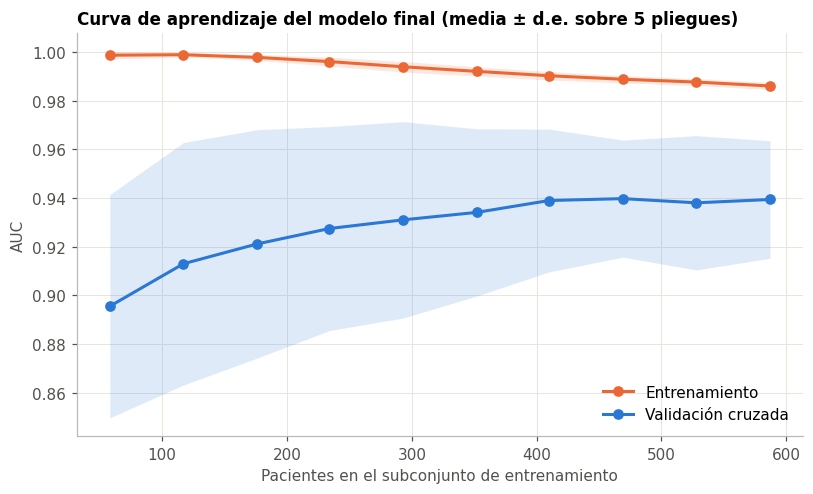

Brecha final entrenamiento − validación: 0.047


In [15]:
tamanos, sc_train, sc_val = learning_curve(modelo, X_train, y_train, cv=cv, scoring="roc_auc",
                                           train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1, shuffle=True,
                                           random_state=mu.RANDOM_STATE)
fig, ax = plt.subplots(figsize=(7.5, 4.6))
for sc, color, etiqueta in [(sc_train, mu.COLORS["pos"], "Entrenamiento"), (sc_val, mu.COLORS["neg"], "Validación cruzada")]:
    m, s = sc.mean(axis=1), sc.std(axis=1)
    ax.plot(tamanos, m, "o-", color=color, ms=6, label=etiqueta)
    ax.fill_between(tamanos, m - s, m + s, color=color, alpha=0.15, linewidth=0)
ax.set_xlabel("Pacientes en el subconjunto de entrenamiento")
ax.set_ylabel("AUC")
ax.legend(loc="lower right")
ax.set_title("Curva de aprendizaje del modelo final (media ± d.e. sobre 5 pliegues)")
fig.tight_layout()
mu.save_figure(fig, "fig08_curva_aprendizaje")
plt.show()
print(f"Brecha final entrenamiento − validación: {sc_train.mean(axis=1)[-1] - sc_val.mean(axis=1)[-1]:.3f}")

**Figura 3.** Curva de aprendizaje: AUC en entrenamiento y en validación cruzada en función del número de pacientes usados para ajustar el pipeline completo.

El modelo reajustado alcanza un AUC de 0.984 en entrenamiento, frente a 0.939 en validación cruzada y 0.935 en prueba. La brecha de 0.047 entre entrenamiento y validación es propia de un ensamble de árboles, que siempre se ajusta con holgura a los datos con que se construye; lo determinante es que validación y prueba coinciden (diferencia de 0.004), es decir, el desempeño estimado se sostiene fuera de la muestra. La curva de aprendizaje refuerza esta lectura: el AUC de validación crece de 0.896 con 58 pacientes a cerca de 0.94 con unos 400, y desde ahí se estabiliza, mientras que el de entrenamiento desciende lentamente desde 0.999. Las curvas convergen sin cruzarse y la de validación ya no mejora de forma apreciable con más datos, de modo que el modelo opera en un régimen de varianza controlada; incorporar más pacientes de la misma población reduciría la brecha, pero difícilmente elevaría el AUC de validación por encima de 0.94.

## 6. Interpretación del modelo

Para identificar las variables en las que se apoya el modelo se usa la importancia por permutación sobre el conjunto de prueba: cada variable original se permuta 30 veces y se mide la caída del AUC. Como el pipeline recibe los datos crudos, la permutación opera sobre las once variables clínicas y no sobre las columnas codificadas, lo que facilita la lectura.

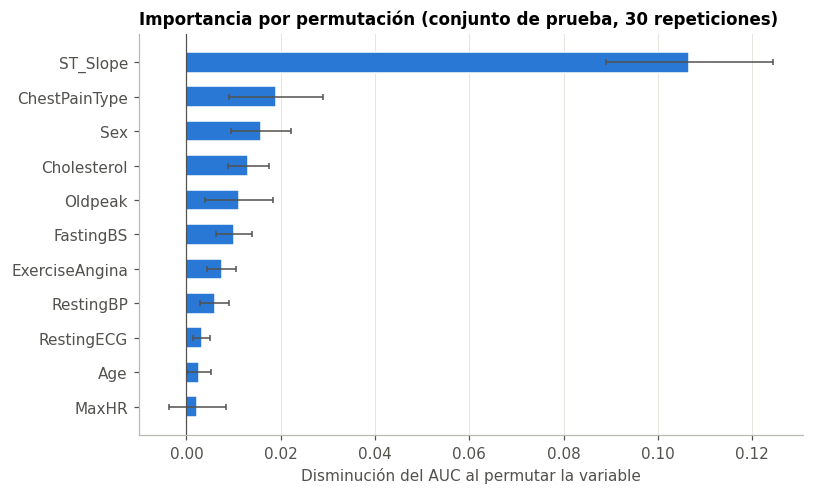

,Variable,Caída media de AUC,d.e.
0,ST_Slope,0.107,0.018
1,ChestPainType,0.019,0.010
2,Sex,0.016,0.006
3,Cholesterol,0.013,0.004
4,Oldpeak,0.011,0.007
5,FastingBS,0.010,0.004
6,ExerciseAngina,0.008,0.003
7,RestingBP,0.006,0.003
8,RestingECG,0.003,0.002
9,Age,0.003,0.002


In [16]:
imp = permutation_importance(modelo, X_test, y_test, scoring="roc_auc", n_repeats=30,
                             random_state=mu.RANDOM_STATE, n_jobs=-1)
importancias = (pd.DataFrame({"Variable": X_test.columns, "Caída media de AUC": imp.importances_mean,
                              "d.e.": imp.importances_std})
                  .sort_values("Caída media de AUC").reset_index(drop=True))
fig, ax = plt.subplots(figsize=(7.5, 4.6))
ax.barh(importancias["Variable"], importancias["Caída media de AUC"], xerr=importancias["d.e."],
        color=mu.COLORS["neg"], height=0.6, edgecolor="white", error_kw=dict(ecolor=mu.COLORS["ink2"], lw=1, capsize=2))
ax.axvline(0, color=mu.COLORS["ink2"], lw=0.8)
ax.set_xlabel("Disminución del AUC al permutar la variable")
ax.grid(axis="y", visible=False)
ax.set_title("Importancia por permutación (conjunto de prueba, 30 repeticiones)")
fig.tight_layout()
mu.save_figure(fig, "fig09_importancia_permutacion")
plt.show()
importancias.sort_values("Caída media de AUC", ascending=False).reset_index(drop=True)

**Figura 4.** Importancia por permutación de las variables clínicas (media ± d.e.).

`ST_Slope` domina con claridad: permutarla reduce el AUC en 0.107, cinco veces más que cualquier otra variable. Le siguen `ChestPainType` (0.019), `Sex` (0.016) y `Cholesterol` (0.013), cuya importancia procede en buena medida del indicador de ausencia y confirma que conservarlo fue una decisión acertada. `Oldpeak`, `FastingBS` y `ExerciseAngina` aportan entre 0.008 y 0.011. Llama la atención la baja importancia de `MaxHR` (0.002 ± 0.006), pese a ser una de las variables con mayor asociación univariada en la Etapa 1. La explicación es la redundancia: su información se solapa con la de `ST_Slope`, `ExerciseAngina` y `Oldpeak` (todas reflejan la respuesta al esfuerzo), de modo que, al permutarla, el ensamble compensa con las variables correlacionadas. La importancia por permutación mide contribución marginal dado el resto del modelo, no relevancia clínica, y debe leerse en ese sentido.

## 7. Exportación del modelo para despliegue

El pipeline completo, preprocesamiento incluido, se serializa con `joblib` en `app/model.joblib`, la ruta que consume la API de FastAPI y que copia el `Dockerfile`; se deja además una copia en la raíz del repositorio (`model.joblib`), tal como figura en la estructura de la Etapa 0. Junto al modelo se guardan sus metadatos (métricas, versiones de las librerías y orden de las variables que espera la API) y los conjuntos de referencia y actual que usa el monitoreo de deriva de la Etapa 6.

In [17]:
raiz = mu.PROJECT_ROOT
ruta_modelo = raiz / "app" / "model.joblib"
joblib.dump(grid.best_estimator_, ruta_modelo)
shutil.copyfile(ruta_modelo, raiz / "model.joblib")

metadatos = {
    "model_name": "heart-failure-classifier",
    "trained_at_utc": datetime.now(timezone.utc).strftime("%Y-%m-%dT%H:%M:%SZ"),
    "estimator": type(grid.best_estimator_.named_steps["clf"]).__name__,
    "best_params": {k: (repr(v) if not isinstance(v, (int, float, str, type(None))) else v)
                    for k, v in grid.best_params_.items()},
    "features": mu.FEATURES,
    "decision_threshold": 0.5,
    "metrics": {
        "cv_roc_auc_mean": round(float(grid.best_score_), 4),
        "cv_roc_auc_std": round(float(grid.cv_results_["std_test_roc_auc"][grid.best_index_]), 4),
        "test_roc_auc": round(float(auc_test), 4),
        "test_roc_auc_ci95": [round(float(ic_lo), 4), round(float(ic_hi), 4)],
        "test_accuracy": round(float((pred_test == y_test).mean()), 4),
        "test_sensitivity": round(float(tp / (tp + fn)), 4),
        "test_specificity": round(float(tn / (tn + fp)), 4),
    },
    "data": {"source": "Kaggle — fedesoriano/heart-failure-prediction", "n_train": len(y_train),
             "n_test": len(y_test), "random_state": mu.RANDOM_STATE},
    "versions": {"python": platform.python_version(), "scikit-learn": sklearn.__version__,
                 "xgboost": xgboost.__version__, "pandas": pd.__version__, "numpy": np.__version__},
}
(raiz / "app" / "model_metadata.json").write_text(json.dumps(metadatos, indent=2, ensure_ascii=False), encoding="utf-8")

# Conjuntos para el monitoreo de deriva (Etapa 6)
referencia = X_train.assign(HeartDisease=y_train.values, prediction=modelo.predict(X_train))
actual = X_test.assign(HeartDisease=y_test.values, prediction=pred_test)
referencia.to_csv(raiz / "data" / "reference.csv", index=False)
actual.to_csv(raiz / "data" / "current.csv", index=False)

print(f"Modelo exportado: {ruta_modelo.relative_to(raiz)} ({ruta_modelo.stat().st_size / 1024:.1f} KB)")
print(json.dumps(metadatos["metrics"], indent=2))

Modelo exportado: app\model.joblib (163.2 KB)
{
  "cv_roc_auc_mean": 0.9388,
  "cv_roc_auc_std": 0.024,
  "test_roc_auc": 0.9351,
  "test_roc_auc_ci95": [
    0.895,
    0.9686
  ],
  "test_accuracy": 0.8967,
  "test_sensitivity": 0.9118,
  "test_specificity": 0.878
}


Como control final, el modelo se vuelve a cargar desde disco y se comprueba que reproduce exactamente las probabilidades del objeto en memoria y que responde a un paciente presentado en el mismo formato que recibirá la API: una lista con las once variables en el orden de `FEATURES`.

In [18]:
cargado = joblib.load(ruta_modelo)
assert np.allclose(cargado.predict_proba(X_test)[:, 1], proba_test)

paciente = X_test.iloc[0].tolist()
print("Entrada (orden de FEATURES):", paciente)
X_api = pd.DataFrame([paciente], columns=mu.FEATURES)
p = float(cargado.predict_proba(X_api)[0, 1])
print({"heart_disease_probability": round(p, 4), "prediction": int(p > 0.5), "real": int(y_test.iloc[0])})

Entrada (orden de FEATURES): [46, 'M', 'ASY', 115, 0, 0, 'Normal', 113, 'Y', 1.5, 'Flat']
{'heart_disease_probability': 0.951, 'prediction': 1, 'real': 1}


## 8. Conclusiones

La Etapa 2 cumple con las tres exigencias del enunciado. La partición estratificada se realizó antes de cualquier transformación, y la presencia de valores fuera de [0, 1] en prueba demuestra que el escalado se ajustó únicamente con entrenamiento. El preprocesamiento, la reducción de dimensionalidad opcional y el clasificador se encadenaron en un único `Pipeline`, y un `GridSearchCV` con validación cruzada estratificada exploró 652 configuraciones de nueve familias bajo los mismos pliegues.

El modelo seleccionado, un XGBoost con 100 árboles de profundidad 4, logró un AUC de validación cruzada de 0.939 ± 0.024 y, en su única evaluación sobre prueba, un AUC de 0.935 (IC 95 %: 0.895–0.969), con exactitud de 0.897, sensibilidad de 0.912 y especificidad de 0.878. La matriz de confusión muestra errores equilibrados (9 falsos negativos y 10 falsos positivos en 184 pacientes) y la curva ROC de prueba coincide con la de validación cruzada. La curva de aprendizaje indica que el modelo no sobreajusta de forma perjudicial y que el desempeño se ha estabilizado con el tamaño muestral disponible. El análisis del umbral sugiere que, con criterio de tamizaje, un umbral de 0.4 reduciría un tercio de los falsos negativos con una pérdida moderada de especificidad.

El pipeline completo quedó serializado en `app/model.joblib`, acompañado de sus metadatos y de los conjuntos de referencia para el monitoreo de deriva. Las etapas siguientes lo sirven mediante una API REST con FastAPI, lo contenerizan con Docker, lo despliegan en Kubernetes local, automatizan su verificación con GitHub Actions y vigilan la deriva de los datos con Evidently.

## 9. Referencias

- Bradley, A. P. (1997). The use of the area under the ROC curve in the evaluation of machine learning algorithms. *Pattern Recognition*, 30(7), 1145–1159.
- Chen, T. y Guestrin, C. (2016). XGBoost: A scalable tree boosting system. *Proceedings of the 22nd ACM SIGKDD*, 785–794.
- fedesoriano (2021). *Heart Failure Prediction Dataset*. Kaggle. https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction
- Hastie, T., Tibshirani, R. y Friedman, J. (2009). *The Elements of Statistical Learning* (2.ª ed.). Springer. Capítulo 7: Model Assessment and Selection.
- Müller, A. C. y Guido, S. (2016). *Introduction to Machine Learning with Python*. O'Reilly Media. Capítulos 5 y 6.
- Pedregosa, F. et al. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research*, 12, 2825–2830.
- Rubio, L. (2023). *Machine Learning*, capítulo 10: Pipelines. https://lihkir.github.io/MachineLearning/chains_pipelines.html

# Parte III.1. Despliegue local con FastAPI y Docker

**Predicción de falla cardíaca con *pipelines* de aprendizaje automático** · Etapa 3 del proyecto integrador

Manuel Meza · Kevin Clemente — Machine Learning (maestría), Prof. Dr. Lihki Rubio — Octubre de 2026

---

**Resumen.** El pipeline exportado en la Parte II se sirve mediante una API REST construida con FastAPI y se empaqueta en una imagen Docker basada en `python:3.10-slim`. La API conserva el contrato del enunciado (`POST /predict` con una lista de variables y respuesta `heart_disease_probability`, `prediction`) y lo complementa con un endpoint de campos nombrados y validados, una sonda de salud y un endpoint de metadatos. La imagen se construyó y ejecutó en local; el contenedor alcanzó el estado `healthy` y reprodujo exactamente las probabilidades calculadas en el cuaderno.

## 1. Diseño de la API

El archivo `app/api.py` carga una única vez el objeto `model.joblib`, que contiene el `Pipeline` completo: imputación, escalado, codificación y clasificador. En consecuencia, la API recibe las variables clínicas en crudo y no replica ninguna lógica de preprocesamiento, lo que elimina la principal fuente de desajuste entre entrenamiento y producción (*training-serving skew*).

El enunciado propone transformar la entrada con `np.array(data.features).reshape(1, -1)`. Esa conversión no es aplicable a este modelo, porque el `ColumnTransformer` selecciona las columnas por nombre y mezcla variables de texto y numéricas, que un arreglo de NumPy convertiría a un único tipo. La API conserva el mismo esquema de entrada, una lista con las once variables, pero la convierte en un `DataFrame` con los nombres de columna en el orden de `FEATURES`, valida la longitud y el tipo de cada valor y responde con un error 422 ante entradas mal formadas.

| Método | Ruta | Descripción |
|---|---|---|
| GET | `/` | Información del servicio y orden esperado de las variables |
| GET | `/health` | Sonda de vida y disponibilidad, usada por Docker y Kubernetes |
| GET | `/model-info` | Estimador, métricas de validación y prueba y fecha de entrenamiento |
| POST | `/predict` | Contrato del enunciado: lista ordenada de 11 valores |
| POST | `/predict/patient` | Objeto con campos nombrados; las categorías y los rangos se validan con Pydantic |

El orden de `features` es `Age, Sex, ChestPainType, RestingBP, Cholesterol, FastingBS, RestingECG, MaxHR, ExerciseAngina, Oldpeak, ST_Slope`. La clase predicha usa el umbral de 0.5 del enunciado (`prediction = int(proba > 0.5)`).

*app/api.py*

```python
"""API REST para predecir el riesgo de falla cardíaca.

El modelo servido es el pipeline completo exportado por
``notebooks/2_model_pipeline_cv.ipynb`` (preprocesamiento + clasificador),
de modo que la API recibe las variables clínicas en crudo.

Endpoints
---------
GET  /                 Información general del servicio.
GET  /health           Sonda de vida y disponibilidad (Docker y Kubernetes).
GET  /model-info       Metadatos y métricas del modelo desplegado.
POST /predict          Predicción a partir de una lista ordenada de variables.
POST /predict/patient  Predicción a partir de un objeto con campos nombrados.
"""

import json
import os
from pathlib import Path
from typing import Literal

import joblib
import pandas as pd
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel, Field

APP_DIR = Path(__file__).resolve().parent
MODEL_PATH = Path(os.getenv("MODEL_PATH", APP_DIR / "model.joblib"))
METADATA_PATH = APP_DIR / "model_metadata.json"
THRESHOLD = 0.5

# Orden en que deben llegar las variables en el endpoint /predict.
FEATURES = [
    "Age", "Sex", "ChestPainType", "RestingBP", "Cholesterol", "FastingBS",
    "RestingECG", "MaxHR", "ExerciseAngina", "Oldpeak", "ST_Slope",
]
NUMERIC = {"Age", "RestingBP", "Cholesterol", "FastingBS", "MaxHR", "Oldpeak"}

model = joblib.load(MODEL_PATH)
metadata = (json.loads(METADATA_PATH.read_text(encoding="utf-8"))
            if METADATA_PATH.exists() else {})

app = FastAPI(
    title="Heart Failure Prediction API",
    description=(
        "Servicio de inferencia del proyecto integrador de MLOps. "
        "Devuelve la probabilidad estimada de enfermedad cardíaca "
        "(HeartDisease = 1) y la clase predicha con umbral 0.5."
    ),
    version="1.0.0",
)


class Input(BaseModel):
    """Lista con las 11 variables en el orden de ``FEATURES``."""

    features: list = Field(
        ...,
        description="Valores en el orden: " + ", ".join(FEATURES),
        json_schema_extra={"example": [54, "M", "ASY", 140, 239, 0,
                                       "Normal", 160, "N", 1.2, "Flat"]},
    )


class Patient(BaseModel):
    """Paciente descrito con campos nombrados y validados."""

    Age: int = Field(..., ge=1, le=120, examples=[54])
    Sex: Literal["M", "F"] = Field(..., examples=["M"])
    ChestPainType: Literal["TA", "ATA", "NAP", "ASY"] = Field(
        ..., examples=["ASY"])
    RestingBP: float = Field(..., ge=0, le=300, examples=[140])
    Cholesterol: float = Field(..., ge=0, le=1000, examples=[239])
    FastingBS: Literal[0, 1] = Field(..., examples=[0])
    RestingECG: Literal["Normal", "ST", "LVH"] = Field(
        ..., examples=["Normal"])
    MaxHR: float = Field(..., ge=40, le=250, examples=[160])
    ExerciseAngina: Literal["Y", "N"] = Field(..., examples=["N"])
    Oldpeak: float = Field(..., ge=-5, le=10, examples=[1.2])
    ST_Slope: Literal["Up", "Flat", "Down"] = Field(..., examples=["Flat"])


class Prediction(BaseModel):
    heart_disease_probability: float
    prediction: int


def _to_frame(values: list) -> pd.DataFrame:
    """Convierte la lista ordenada en el DataFrame que espera el pipeline."""
    if len(values) != len(FEATURES):
        raise HTTPException(
            status_code=422,
            detail=(f"Se esperaban {len(FEATURES)} valores en el orden "
                    f"{FEATURES}; se recibieron {len(values)}."),
        )
    row = {}
    for name, value in zip(FEATURES, values):
        if name in NUMERIC:
            try:
                row[name] = float(value)
            except (TypeError, ValueError) as exc:
                raise HTTPException(
                    status_code=422,
                    detail=f"'{name}' debe ser numérico; recibido: {value!r}",
                ) from exc
        else:
            row[name] = str(value)
    return pd.DataFrame([row], columns=FEATURES)


def _predict(X: pd.DataFrame) -> dict:
    proba = float(model.predict_proba(X)[0][1])
    return {"heart_disease_probability": proba,
            "prediction": int(proba > THRESHOLD)}


@app.get("/")
def root():
    return {
        "service": "heart-failure-prediction",
        "docs": "/docs",
        "endpoints": ["/health", "/model-info", "/predict",
                      "/predict/patient"],
        "features_order": FEATURES,
    }


@app.get("/health")
def health():
    return {"status": "ok", "model_loaded": model is not None}


@app.get("/model-info")
def model_info():
    return {
        "estimator": metadata.get("estimator"),
        "metrics": metadata.get("metrics"),
        "trained_at_utc": metadata.get("trained_at_utc"),
        "features": FEATURES,
        "decision_threshold": THRESHOLD,
    }


@app.post("/predict", response_model=Prediction)
def predict(data: Input):
    return _predict(_to_frame(data.features))


@app.post("/predict/patient", response_model=Prediction)
def predict_patient(patient: Patient):
    return _predict(pd.DataFrame([patient.model_dump()], columns=FEATURES))
```

## 2. Exportación del modelo

La exportación se realiza al final de la Parte II con `joblib.dump(grid.best_estimator_, "app/model.joblib")`, como indica el enunciado. Se deja una copia en la raíz del repositorio (`model.joblib`), conforme a la estructura de la Etapa 0, y se guarda `app/model_metadata.json` con las métricas, los hiperparámetros, el orden de las variables y las versiones de las librerías. Una prueba automática verifica que ambas copias sean idénticas byte a byte y que las métricas declaradas coincidan con las que el modelo reproduce sobre el conjunto de prueba.

## 3. Imagen Docker

El `Dockerfile` sigue el del enunciado y añade cuatro prácticas de producción: variables de entorno que evitan archivos `.pyc` y el búfer de salida, un usuario sin privilegios, la declaración del puerto expuesto y un `HEALTHCHECK` que consulta `/health` cada 30 segundos. Las dependencias están fijadas a las versiones exactas con que se entrenó el modelo, porque un objeto serializado con `joblib` solo es portable entre versiones compatibles de scikit-learn y XGBoost. Se usa `xgboost-cpu`, que contiene la misma clase `XGBClassifier` pero excluye las bibliotecas de GPU, innecesarias para inferencia y responsables de varios cientos de megabytes. El archivo `.dockerignore` excluye datos, cuadernos y reportes del contexto de construcción.

*docker/Dockerfile*

```docker
# Imagen de inferencia del modelo de falla cardíaca (Etapa 3).
# Construcción desde la raíz del repositorio:
#   docker build -t heart-api -f docker/Dockerfile .
FROM python:3.10-slim

ENV PYTHONDONTWRITEBYTECODE=1 \
    PYTHONUNBUFFERED=1 \
    PIP_DISABLE_PIP_VERSION_CHECK=1

WORKDIR /app
COPY docker/requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

COPY app/ ./app/

# Ejecución con un usuario sin privilegios
RUN useradd --create-home --uid 1000 appuser
USER appuser

EXPOSE 8000
HEALTHCHECK --interval=30s --timeout=5s --start-period=20s --retries=3 \
  CMD python -c "import urllib.request; urllib.request.urlopen('http://localhost:8000/health')" || exit 1

CMD ["uvicorn", "app.api:app", "--host", "0.0.0.0", "--port", "8000"]
```

*docker/requirements.txt*

```text
fastapi==0.115.6
uvicorn==0.34.0
scikit-learn==1.6.1
joblib==1.4.2
pydantic==2.10.4
pandas==2.2.3
numpy==1.26.4
xgboost-cpu==3.0.5
```

Construcción y ejecución local, desde la raíz del repositorio:

```bash
docker build -t heart-api -f docker/Dockerfile .
docker run -p 8000:8000 heart-api
```

## 4. Evidencia de ejecución

La API se ejecutó primero con `uvicorn` y luego dentro del contenedor, en Windows 11 con Docker Desktop 29.8. La imagen resultante ocupa 159 MB comprimida y el contenedor alcanza el estado `healthy` tras el periodo de arranque del `HEALTHCHECK`.

*Imagen construida y estado de salud del contenedor*

```text
> docker images heart-api
IMAGE              ID             DISK USAGE   CONTENT SIZE   EXTRA
heart-api:latest   018212f7310e        690MB          159MB        

> docker ps --filter name=heart-api-health   (tras el periodo de arranque del HEALTHCHECK)
CONTAINER ID   IMAGE       COMMAND                  CREATED         STATUS                   PORTS                                         NAMES
faf8712666d1   heart-api   "uvicorn app.api:app…"   6 seconds ago   Up 6 seconds (healthy)   0.0.0.0:8001->8000/tcp, [::]:8001->8000/tcp   heart-api-health
Estado de salud del contenedor: healthy
```

*Respuesta de /health y /predict desde el contenedor*

```json
{
    "comando":  "docker run -p 8000:8000 heart-api",
    "health":  {
                   "status":  "ok",
                   "model_loaded":  true
               },
    "predict_request":  {
                            "features":  [
                                             54,
                                             "M",
                                             "ASY",
                                             140,
                                             239,
                                             0,
                                             "Normal",
                                             160,
                                             "N",
                                             1.2,
                                             "Flat"
                                         ]
                        },
    "predict_response":  {
                             "heart_disease_probability":  0.7452462315559387,
                             "prediction":  1
                         }
}
```

*API servida con uvicorn, incluido el rechazo de una entrada de longitud incorrecta*

```text
# API ejecutada localmente con: uvicorn app.api:app --port 8765
GET /health
{"status":"ok","model_loaded":true}
POST /predict {"features":[54,"M","ASY",140,239,0,"Normal",160,"N",1.2,"Flat"]}
{"heart_disease_probability":0.7452462315559387,"prediction":1}
POST /predict {"features":[54,"M","ASY"]}  (longitud inválida)
{"detail":"Se esperaban 11 valores en el orden ['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope']; se recibieron 3."}
```

La probabilidad devuelta para el paciente de ejemplo, 0.7452, es idéntica en la ejecución con `uvicorn`, en el contenedor y en el clúster de Kubernetes (Parte III.2), lo que confirma que el artefacto desplegado es exactamente el modelo evaluado. El registro completo de la construcción sin caché se encuentra en `reports/evidence/03_docker_build.log`.

# Parte III.2. Orquestación con Kubernetes local

**Predicción de falla cardíaca con *pipelines* de aprendizaje automático** · Etapa 4 del proyecto integrador

Manuel Meza · Kevin Clemente — Machine Learning (maestría), Prof. Dr. Lihki Rubio — Octubre de 2026

---

**Resumen.** El contenedor de la Parte III.1 se despliega en un clúster local de Kubernetes creado con Minikube (Kubernetes 1.37). Un `Deployment` mantiene dos réplicas del servicio con sondas de disponibilidad y de vida, y un `Service` de tipo `LoadBalancer` las expone en el puerto 80. El despliegue completó su *rollout*, respondió predicciones a través del `Service` y escaló a tres réplicas sin interrupción.

## 1. Manifiestos

El `Deployment` parte del manifiesto del enunciado y lo completa en tres aspectos. La imagen, indicada en el enunciado como `<TU_USUARIO_DOCKER>/heart-api`, se publica en GitHub Container Registry desde el flujo de integración continua (`ghcr.io/santiagomezac/heart-api:latest`), lo que evita gestionar credenciales de Docker Hub; con `imagePullPolicy: IfNotPresent`, Minikube usa la imagen construida localmente si ya está cargada y, en otro caso, la descarga del registro público. El número de réplicas se eleva de una a dos para que el `Service` tenga más de un destino y el servicio sobreviva a la caída de un pod. Por último, se declaran solicitudes y límites de CPU y memoria y dos sondas HTTP sobre `/health`: la de disponibilidad (*readiness*) impide que el `Service` envíe tráfico a un pod que aún está cargando el modelo, y la de vida (*liveness*) reinicia el contenedor si deja de responder.

*k8s/deployment.yaml*

```yaml
# Etapa 4 — Deployment del servicio de inferencia.
# La imagen se publica en GitHub Container Registry desde el workflow de CI.
# En Minikube puede usarse también la imagen construida localmente:
#   minikube image load ghcr.io/santiagomezac/heart-api:latest
apiVersion: apps/v1
kind: Deployment
metadata:
  name: heart-model
  labels:
    app: heart-model
spec:
  replicas: 2
  selector:
    matchLabels:
      app: heart-model
  template:
    metadata:
      labels:
        app: heart-model
    spec:
      containers:
      - name: model
        image: ghcr.io/santiagomezac/heart-api:latest
        imagePullPolicy: IfNotPresent
        ports:
        - containerPort: 8000
        resources:
          requests:
            cpu: 100m
            memory: 256Mi
          limits:
            cpu: 500m
            memory: 512Mi
        readinessProbe:
          httpGet:
            path: /health
            port: 8000
          initialDelaySeconds: 5
          periodSeconds: 10
        livenessProbe:
          httpGet:
            path: /health
            port: 8000
          initialDelaySeconds: 15
          periodSeconds: 20
```

*k8s/service.yaml*

```yaml
# Etapa 4 — Service que expone el Deployment en el puerto 80.
# En Minikube, una IP externa para el LoadBalancer requiere `minikube tunnel`;
# alternativamente: `minikube service heart-service --url`.
apiVersion: v1
kind: Service
metadata:
  name: heart-service
spec:
  selector:
    app: heart-model
  ports:
    - protocol: TCP
      port: 80
      targetPort: 8000
  type: LoadBalancer
```

## 2. Despliegue en Minikube

```bash
minikube start --driver=docker
minikube image load ghcr.io/santiagomezac/heart-api:latest
kubectl apply -f k8s/deployment.yaml
kubectl apply -f k8s/service.yaml
kubectl get svc
```

En Minikube un `Service` de tipo `LoadBalancer` permanece con `EXTERNAL-IP` en estado `<pending>` porque no existe un balanceador de nube que le asigne una dirección. Para obtenerla se ejecuta `minikube tunnel` en una terminal aparte; alternativamente, `minikube service heart-service --url` devuelve una URL accesible a través del `NodePort` que Kubernetes asigna automáticamente, y `kubectl port-forward svc/heart-service 8080:80` redirige un puerto local al `Service`. La secuencia completa, con la prueba del `Service` y el escalado, está automatizada en `scripts/deploy_local.ps1`.

## 3. Evidencia de ejecución

*Estado del Deployment, los pods y el Service tras el rollout*

```text
> kubectl get deployments,pods,svc -o wide
NAME                          READY   UP-TO-DATE   AVAILABLE   AGE   CONTAINERS   IMAGES                                   SELECTOR
deployment.apps/heart-model   2/2     2            2           12s   model        ghcr.io/santiagomezac/heart-api:latest   app=heart-model

NAME                               READY   STATUS    RESTARTS   AGE   IP           NODE       NOMINATED NODE   READINESS GATES
pod/heart-model-5bfdc96cb4-8mtl7   1/1     Running   0          12s   10.244.0.3   minikube   <none>           <none>
pod/heart-model-5bfdc96cb4-msvqc   1/1     Running   0          12s   10.244.0.4   minikube   <none>           <none>

NAME                    TYPE           CLUSTER-IP       EXTERNAL-IP   PORT(S)        AGE   SELECTOR
service/heart-service   LoadBalancer   10.111.143.225   <pending>     80:32181/TCP   12s   app=heart-model
service/kubernetes      ClusterIP      10.96.0.1        <none>        443/TCP        44s   <none>
```

*Predicción servida a través del Service*

```json
{
    "comando":  "kubectl port-forward svc/heart-service 8080:80",
    "health":  {
                   "status":  "ok",
                   "model_loaded":  true
               },
    "predict_request":  {
                            "features":  [
                                             54,
                                             "M",
                                             "ASY",
                                             140,
                                             239,
                                             0,
                                             "Normal",
                                             160,
                                             "N",
                                             1.2,
                                             "Flat"
                                         ]
                        },
    "predict_response":  {
                             "heart_disease_probability":  0.7452462315559387,
                             "prediction":  1
                         }
}
```

*Escalado horizontal a tres réplicas*

```text
> kubectl scale deployment/heart-model --replicas=3
deployment.apps/heart-model scaled
> kubectl rollout status deployment/heart-model --timeout=180s
Waiting for deployment "heart-model" rollout to finish: 2 of 3 updated replicas are available...
deployment "heart-model" successfully rolled out
> kubectl get pods -l app=heart-model -o wide
NAME                           READY   STATUS    RESTARTS   AGE   IP           NODE       NOMINATED NODE   READINESS GATES
heart-model-5bfdc96cb4-7vmfg   1/1     Running   0          11s   10.244.0.5   minikube   <none>           <none>
heart-model-5bfdc96cb4-8mtl7   1/1     Running   0          24s   10.244.0.3   minikube   <none>           <none>
heart-model-5bfdc96cb4-msvqc   1/1     Running   0          24s   10.244.0.4   minikube   <none>           <none>
```

Las dos réplicas alcanzaron el estado `Running` y quedaron disponibles (2/2) en menos de 15 segundos. El `Service` recibió la IP de clúster 10.111.143.225 y el `NodePort` 32181, y respondió la misma probabilidad (0.7452) que el contenedor aislado. El escalado a tres réplicas se completó sin interrumpir el servicio, porque las sondas de disponibilidad retienen el tráfico hacia el pod nuevo hasta que carga el modelo. El mismo despliegue se repite en cada ejecución del flujo de integración continua sobre un clúster efímero creado con kind (Parte III.3).

# Parte III.3. Integración continua con GitHub Actions

**Predicción de falla cardíaca con *pipelines* de aprendizaje automático** · Etapa 5 del proyecto integrador

Manuel Meza · Kevin Clemente — Machine Learning (maestría), Prof. Dr. Lihki Rubio — Octubre de 2026

---

**Resumen.** El flujo `.github/workflows/ci.yml` se ejecuta en cada `push` y *pull request*. Además de la revisión de estilo y las pruebas que pide el enunciado, construye la imagen Docker y la prueba, la publica en GitHub Container Registry, la despliega en un clúster efímero de Kubernetes y genera los reportes de deriva de datos. La ejecución de referencia completó sus cuatro trabajos sin errores en menos de cuatro minutos.

## 1. Estructura del flujo

El trabajo `build` reproduce el flujo del enunciado: instala las dependencias de la imagen (`docker/requirements.txt`), ejecuta `flake8` y corre `pytest tests/`. Respecto del enunciado se introducen tres cambios. Las acciones se actualizan de `checkout@v3` y `setup-python@v4` a sus versiones vigentes, porque las originales dependen de versiones de Node.js retiradas de los *runners* de GitHub. Se instala `httpx`, que exige el `TestClient` de FastAPI. Y el lint se extiende al directorio de pruebas.

Sobre ese trabajo se encadenan otros tres. `docker` construye la imagen, la ejecuta y verifica que `/predict` devuelva una probabilidad válida; en la rama `main` la publica en `ghcr.io/santiagomezac/heart-api` con las etiquetas `latest` y el identificador del *commit*, usando el `GITHUB_TOKEN` del propio flujo. `kubernetes` crea un clúster con kind, carga la imagen recién construida, aplica los manifiestos de `k8s/`, espera el *rollout* y consulta el `Service`. `drift`, que corre en paralelo, ejecuta `monitoring/drift_report.py` y publica los reportes HTML como artefactos descargables.

```mermaid
P[push / pull request] --> B[build<br/>flake8 + pytest]
  B --> D[docker<br/>build + prueba de humo<br/>+ push a GHCR]
  D --> K[kubernetes<br/>kind + kubectl apply<br/>+ prueba del Service]
  B --> M[drift<br/>reportes de Evidently]
```

*.github/workflows/ci.yml*

```yaml
name: CI

on: [push, pull_request, workflow_dispatch]

env:
  IMAGE: ghcr.io/santiagomezac/heart-api

jobs:
  # Etapa 5 — linting y pruebas automáticas en cada push
  build:
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v7
      - name: Set up Python
        uses: actions/setup-python@v7
        with:
          python-version: '3.10'
          cache: pip
          cache-dependency-path: docker/requirements.txt
      - name: Install dependencies
        run: |
          pip install -r docker/requirements.txt
          pip install flake8 pytest httpx
      - name: Lint
        run: flake8 app/ tests/
      - name: Tests
        run: pytest tests/ -v

  # Etapa 3 en CI — construcción de la imagen y prueba de humo del contenedor
  docker:
    needs: build
    runs-on: ubuntu-latest
    permissions:
      contents: read
      packages: write
    steps:
      - uses: actions/checkout@v7
      - name: Build image
        run: docker build -t heart-api -f docker/Dockerfile .
      - name: Smoke test
        run: |
          docker run -d --name heart -p 8000:8000 heart-api
          for i in $(seq 1 30); do curl -sf localhost:8000/health && break; sleep 1; done
          curl -sf -X POST localhost:8000/predict \
            -H "Content-Type: application/json" \
            -d '{"features":[54,"M","ASY",140,239,0,"Normal",160,"N",1.2,"Flat"]}' | tee response.json
          python3 -c "import json; r = json.load(open('response.json')); assert 0 <= r['heart_disease_probability'] <= 1"
          docker rm -f heart
      - name: Save image
        run: |
          docker tag heart-api ${{ env.IMAGE }}:latest
          docker save ${{ env.IMAGE }}:latest -o heart-api.tar
      - uses: actions/upload-artifact@v7
        with:
          name: heart-api-image
          path: heart-api.tar
          retention-days: 3
      - name: Push to GHCR
        if: github.ref == 'refs/heads/main' && github.event_name != 'pull_request'
        run: |
          echo "${{ secrets.GITHUB_TOKEN }}" | docker login ghcr.io -u ${{ github.actor }} --password-stdin
          docker tag heart-api ${{ env.IMAGE }}:${{ github.sha }}
          docker push ${{ env.IMAGE }}:latest
          docker push ${{ env.IMAGE }}:${{ github.sha }}

  # Etapa 4 en CI — despliegue de los manifiestos en un clúster efímero (kind)
  kubernetes:
    needs: docker
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v7
      - uses: actions/download-artifact@v8
        with:
          name: heart-api-image
      - name: Create kind cluster
        uses: helm/kind-action@v1
        with:
          cluster_name: heart
      - name: Load image and deploy
        run: |
          kind load image-archive heart-api.tar --name heart
          kubectl apply -f k8s/deployment.yaml
          kubectl apply -f k8s/service.yaml
          kubectl rollout status deployment/heart-model --timeout=180s
          kubectl get pods,svc -o wide
      - name: Test service
        run: |
          kubectl port-forward svc/heart-service 8080:80 &
          for i in $(seq 1 30); do curl -sf localhost:8080/health && break; sleep 1; done
          curl -sf -X POST localhost:8080/predict \
            -H "Content-Type: application/json" \
            -d '{"features":[65,"M","ASY",150,0,1,"ST",100,"Y",2.5,"Flat"]}'

  # Etapa 6 en CI — reporte de deriva de datos con Evidently
  drift:
    needs: build
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v7
      - uses: actions/setup-python@v7
        with:
          python-version: '3.10'
      - name: Install monitoring dependencies
        run: pip install -r monitoring/requirements.txt
      - name: Generate drift reports
        run: python monitoring/drift_report.py
      - uses: actions/upload-artifact@v7
        with:
          name: drift-reports
          path: |
            drift_report.html
            reports/drift_report_simulated.html
            reports/drift_summary.json
```

## 2. Pruebas automáticas

Las 16 pruebas cubren dos dimensiones. `tests/test_api.py` verifica el contrato del servicio: la sonda de salud, el formato y el rango de la respuesta, la coherencia entre la probabilidad y la clase, que un perfil clínico de alto riesgo se clasifique como positivo y uno de bajo riesgo como negativo, la equivalencia entre los dos endpoints de predicción, el rechazo con código 422 de listas incompletas, valores no numéricos y categorías inválidas, y la tolerancia a categorías no vistas durante el entrenamiento. `tests/test_model.py` actúa como compuerta de calidad del modelo: exige un AUC de prueba de al menos 0.90 y una exactitud de al menos 0.85, comprueba que el artefacto sea el pipeline completo con las variables en el orden esperado y que los metadatos y la copia en la raíz sean consistentes. Si un reentrenamiento futuro degradara el modelo por debajo de esos umbrales, el flujo fallaría y la imagen no se publicaría.

*Ejecución local de las pruebas*

```text
============================= test session starts =============================
platform win32 -- Python 3.10.21, pytest-8.3.4, pluggy-1.6.0 -- C:\Users\User\miniconda3\envs\heart-mlops\python.exe
rootdir: C:\Users\User\Desktop\GEOLOGÍA\MAESTRÍA\Semestre 2\MachineLearning\heart-disease-mlops
configfile: pytest.ini
plugins: anyio-4.15.1, Faker-40.40.0, platformdirs-4.12.3
collecting ... collected 16 items

tests/test_api.py::test_root_lists_feature_order PASSED                  [  6%]
tests/test_api.py::test_health PASSED                                    [ 12%]
tests/test_api.py::test_model_info_has_metrics PASSED                    [ 18%]
tests/test_api.py::test_predict_contract[values0] PASSED                 [ 25%]
tests/test_api.py::test_predict_contract[values1] PASSED                 [ 31%]
tests/test_api.py::test_predict_separates_clinical_profiles PASSED       [ 37%]
tests/test_api.py::test_both_endpoints_agree PASSED                      [ 43%]
tests/test_api.py::test_predict_rejects_wrong_length PASSED              [ 50%]
tests/test_api.py::test_predict_rejects_non_numeric_value PASSED         [ 56%]
tests/test_api.py::test_patient_rejects_invalid_category PASSED          [ 62%]
tests/test_api.py::test_predict_tolerates_unseen_category PASSED         [ 68%]
tests/test_model.py::test_model_is_full_pipeline PASSED                  [ 75%]
tests/test_model.py::test_model_meets_auc_threshold PASSED               [ 81%]
tests/test_model.py::test_model_meets_accuracy_threshold PASSED          [ 87%]
tests/test_model.py::test_metadata_matches_model PASSED                  [ 93%]
tests/test_model.py::test_root_copy_is_identical PASSED                  [100%]

============================== warnings summary ===============================
tests/test_api.py::test_predict_tolerates_unseen_category

-- Docs: https://docs.pytest.org/en/stable/how-to/capture-warnings.html
======================== 16 passed, 1 warning in 2.64s ========================
```

## 3. Resultado de la ejecución

| Trabajo | Resultado | Duración |
|---|---|---|
| `build` (lint y pruebas) | Exitoso | 29 s |
| `docker` (imagen, prueba de humo y publicación) | Exitoso | 79 s |
| `kubernetes` (despliegue en kind) | Exitoso | 79 s |
| `drift` (reportes de Evidently) | Exitoso | 53 s |

El historial completo de ejecuciones puede consultarse en la pestaña [Actions](https://github.com/SantiagomezaC/heart-disease-mlops/actions) del repositorio, y la imagen publicada en [`ghcr.io/santiagomezac/heart-api`](https://github.com/SantiagomezaC/heart-disease-mlops/pkgs/container/heart-api), desde donde puede descargarse con `docker pull ghcr.io/santiagomezac/heart-api:latest`.

# Parte IV. Monitoreo de deriva de datos con Evidently

**Predicción de falla cardíaca con *pipelines* de aprendizaje automático** · Etapa 6 del proyecto integrador

Manuel Meza · Kevin Clemente — Machine Learning (maestría), Prof. Dr. Lihki Rubio — Octubre de 2026

---

**Resumen.** Este cuaderno documenta la Etapa 6 del proyecto. Con `Report(metrics=[DataDriftPreset()])` de Evidently se compara la distribución de las variables de entrada y de las predicciones entre el conjunto de entrenamiento (referencia) y dos conjuntos actuales: el de prueba, que proviene de la misma población, y un lote de producción simulado con cambios demográficos y de laboratorio plausibles. Entre entrenamiento y prueba no se detecta deriva del conjunto (1 de 12 columnas, atribuible a comparaciones múltiples); en el lote simulado se detecta deriva en 6 de 12 columnas, incluidas las cuatro perturbadas deliberadamente. El análisis muestra además que la deriva de las entradas no se tradujo en deriva de las predicciones, lo que obliga a distinguir entre ambos fenómenos al definir alertas.

## 1. Introducción

Un modelo desplegado se evalúa con datos que ya no controla. Si la población que llega a la API difiere de la de entrenamiento (deriva de covariables) o si cambia la relación entre las variables y el desenlace (deriva de concepto), el desempeño medido en la Etapa 2 deja de ser representativo. La deriva de concepto solo puede confirmarse cuando se conocen los desenlaces reales, que en un contexto clínico llegan con semanas o meses de retraso; la deriva de covariables, en cambio, puede vigilarse de inmediato comparando distribuciones, y por eso constituye la primera línea del monitoreo.

Evidently implementa esa comparación columna a columna. Para conjuntos de referencia pequeños (menos de 1 000 filas) aplica por defecto la prueba de Kolmogorov-Smirnov a las variables numéricas, la prueba chi-cuadrado a las categóricas y una prueba Z de proporciones a las binarias, con nivel de significancia de 0.05; el conjunto se declara con deriva cuando al menos la mitad de las columnas la presenta. La lógica está implementada en `monitoring/drift_report.py`, que reproduce el código del enunciado y que este cuaderno ejecuta y analiza.

In [1]:
import importlib.util
import json
import sys
import warnings

import evidently
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import ml_utils as mu

warnings.filterwarnings("ignore")
mu.set_plot_style()
pd.set_option("display.precision", 4)

spec = importlib.util.spec_from_file_location("drift_report", mu.PROJECT_ROOT / "monitoring" / "drift_report.py")
drift = importlib.util.module_from_spec(spec)
spec.loader.exec_module(drift)
print(f"Evidently {evidently.__version__}")

Evidently 0.6.7


## 2. Conjuntos comparados

La referencia es el conjunto de entrenamiento (734 pacientes) y los conjuntos actuales son el de prueba (184 pacientes), ambos exportados por `2_model_pipeline_cv.ipynb` junto con la predicción del modelo para cada paciente. El código núcleo es exactamente el del enunciado, ampliado con un `ColumnMapping` que declara el tipo de cada variable para que Evidently aplique la prueba adecuada (sin él, `FastingBS` se trataría como numérica):

```python
from evidently.report import Report
from evidently.metric_preset import DataDriftPreset

report = Report(metrics=[DataDriftPreset()])
report.run(reference_data=X_train, current_data=X_test, column_mapping=COLUMN_MAPPING)
report.save_html("drift_report.html")
```

El segundo conjunto actual simula un cambio en la población atendida: el servicio empieza a recibir pacientes de una unidad de cardiología geriátrica. Se remuestrean 400 pacientes del conjunto de prueba y se modifican cuatro variables: la edad aumenta en promedio 8 años, la frecuencia cardíaca máxima disminuye 12 latidos/min, un 30 % de los pacientes pasa a reportar dolor torácico asintomático y el laboratorio deja de informar el colesterol en el 35 % de los casos. Las predicciones del lote se generan con el modelo desplegado.

In [2]:
referencia, actual = drift.load_sets()
modelo = __import__("joblib").load(mu.PROJECT_ROOT / "app" / "model.joblib")
simulado = drift.simulate_production_batch(actual, modelo)
print(f"Referencia: {referencia.shape} · prueba: {actual.shape} · producción simulada: {simulado.shape}")

resumen = {
    "Entrenamiento vs. prueba": drift.run_report(referencia, actual, mu.PROJECT_ROOT / "drift_report.html"),
    "Entrenamiento vs. producción simulada": drift.run_report(
        referencia, simulado, mu.PROJECT_ROOT / "reports" / "drift_report_simulated.html"),
}
pd.DataFrame({k: {"Deriva del conjunto": v["dataset_drift"],
                  "Columnas evaluadas": v["number_of_columns"],
                  "Columnas con deriva": v["number_of_drifted_columns"],
                  "Proporción con deriva": v["share_of_drifted_columns"],
                  "Umbral de proporción": v["drift_share_threshold"]}
              for k, v in resumen.items()})

Referencia: (734, 12) · prueba: (184, 12) · producción simulada: (400, 12)


,Entrenamiento vs. prueba,Entrenamiento vs. producción simulada
Deriva del conjunto,False,True
Columnas evaluadas,12,12
Columnas con deriva,1,6
Proporción con deriva,0.0833,0.5
Umbral de proporción,0.5,0.5


## 3. Resultados por variable

In [3]:
filas = []
for escenario, r in resumen.items():
    for col, info in r["columns"].items():
        filas.append({"Escenario": escenario, "Columna": col, "Prueba": info["stattest"].replace(" p_value", ""),
                      "p-valor": info["drift_score"], "Deriva (α = 0.05)": info["drift_detected"]})
detalle = pd.DataFrame(filas)
tabla = detalle.pivot(index=["Columna", "Prueba"], columns="Escenario", values=["p-valor", "Deriva (α = 0.05)"])
tabla = tabla.swaplevel(axis=1).sort_index(axis=1, level=0, sort_remaining=False)
orden = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak", "Sex", "ChestPainType", "FastingBS",
         "RestingECG", "ExerciseAngina", "ST_Slope", "prediction"]
tabla = tabla.reindex(orden, level=0)
bonferroni = 0.05 / len(orden)
print(f"Umbral con corrección de Bonferroni para {len(orden)} pruebas: {bonferroni:.4f}")
tabla.style.format("{:.4f}", subset=[c for c in tabla.columns if c[1] == "p-valor"]).set_caption(
    "Tabla 1. p-valores de las pruebas de deriva por columna")

Umbral con corrección de Bonferroni para 12 pruebas: 0.0042


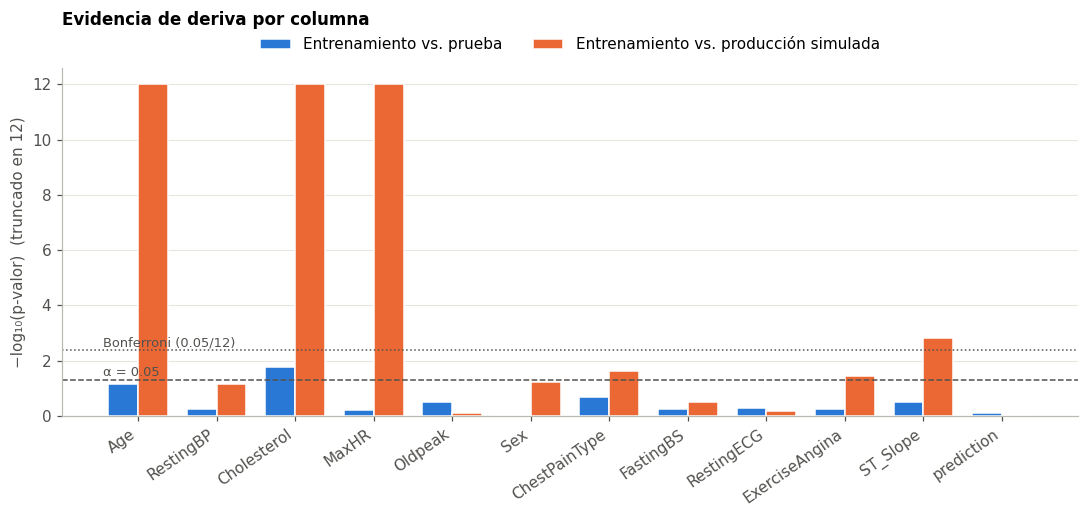

In [4]:
fig, ax = plt.subplots(figsize=(10, 4.8))
x = np.arange(len(orden))
w = 0.38
for k, (escenario, color) in enumerate([("Entrenamiento vs. prueba", mu.COLORS["neg"]),
                                        ("Entrenamiento vs. producción simulada", mu.COLORS["pos"])]):
    d = detalle[detalle["Escenario"] == escenario].set_index("Columna").loc[orden]
    valores = np.clip(-np.log10(d["p-valor"].clip(lower=1e-12)), 0, 12)
    ax.bar(x + (k - 0.5) * w, valores, width=w, color=color, edgecolor="white", label=escenario)
ax.axhline(-np.log10(0.05), color=mu.COLORS["ink2"], ls="--", lw=1)
ax.text(-0.45, -np.log10(0.05) + 0.15, "α = 0.05", ha="left", fontsize=8.5, color=mu.COLORS["ink2"])
ax.axhline(-np.log10(bonferroni), color=mu.COLORS["ink2"], ls=":", lw=1)
ax.text(-0.45, -np.log10(bonferroni) + 0.15, "Bonferroni (0.05/12)", ha="left", fontsize=8.5,
        color=mu.COLORS["ink2"])
ax.set_xticks(x, orden, rotation=35, ha="right")
ax.set_ylabel("−log₁₀(p-valor)  (truncado en 12)")
ax.grid(axis="x", visible=False)
ax.legend(loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.13))
ax.set_title("Evidencia de deriva por columna", pad=28)
fig.tight_layout()
mu.save_figure(fig, "fig10_deriva_pvalores")
plt.show()

**Figura 1.** Evidencia de deriva por columna, expresada como −log₁₀ del p-valor de la prueba que Evidently asigna a cada tipo de variable. Las barras que superan la línea discontinua corresponden a deriva detectada con α = 0.05; la línea punteada marca el umbral corregido por Bonferroni.

Entre entrenamiento y prueba, once de las doce columnas tienen p-valores entre 0.07 y 0.96, y solo `Cholesterol` cruza el umbral (p = 0.017). Ese resultado no indica un problema en la partición. Con doce pruebas a α = 0.05, la probabilidad de al menos una falsa alarma bajo la hipótesis nula es 1 − 0.95¹² ≈ 0.46, y con la corrección de Bonferroni (umbral 0.0042) ninguna columna resulta significativa. Además, la Figura 2 muestra el origen concreto de la diferencia: la partición aleatoria dejó un 23.4 % de colesteroles no reportados en prueba frente a un 17.6 % en entrenamiento, y la prueba de Kolmogorov-Smirnov es muy sensible a cambios en la masa puntual en cero. La regla de nivel de conjunto de Evidently, que exige deriva en al menos la mitad de las columnas, absorbe correctamente esta alarma aislada (1 de 12, 8.3 %).

En el lote simulado, las tres variables numéricas perturbadas presentan p-valores inferiores a 10⁻¹² y `ChestPainType` registra p = 0.024. La deriva también aparece en `ST_Slope` (p = 0.0015) y `ExerciseAngina` (p = 0.035), que no se modificaron. Su origen es metodológico: el lote se obtuvo remuestreando con reemplazo los 184 pacientes de prueba hasta 400, de modo que las pequeñas diferencias que la prueba ya tenía con el entrenamiento (p = 0.31 y 0.57) se replican con un tamaño muestral inflado por filas duplicadas, lo que viola el supuesto de independencia y aumenta artificialmente la potencia. Con seis columnas en deriva sobre doce, la proporción alcanza exactamente el umbral de 0.5 y el conjunto se declara con deriva.

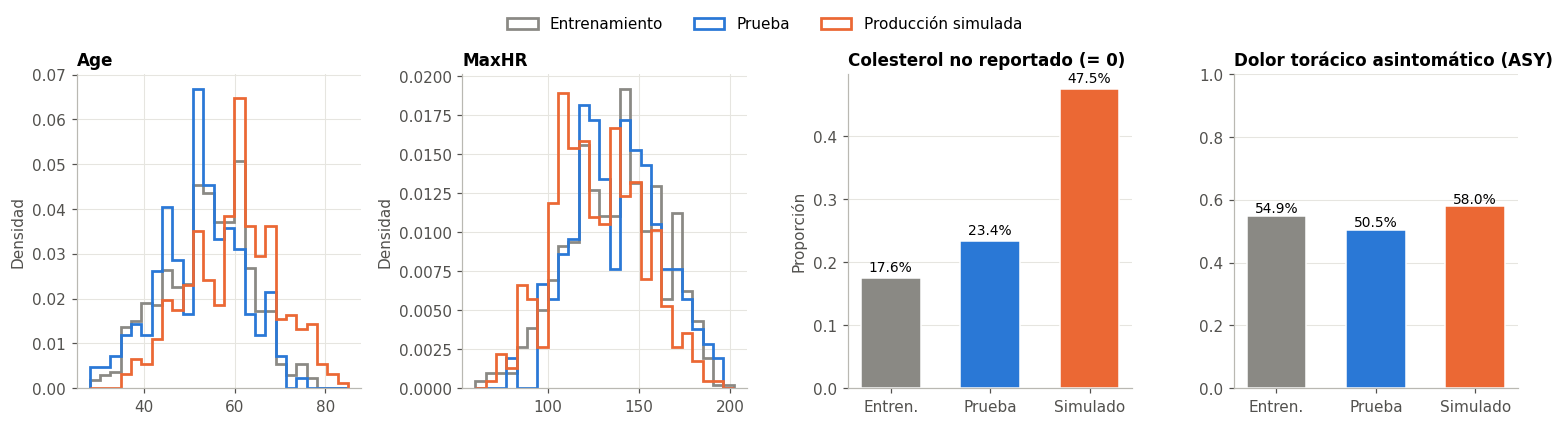

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.6))
conjuntos = [("Entrenamiento", referencia, mu.COLORS["muted"]), ("Prueba", actual, mu.COLORS["neg"]),
             ("Producción simulada", simulado, mu.COLORS["pos"])]
for ax, var in zip(axes[:2], ["Age", "MaxHR"]):
    bins = np.histogram_bin_edges(pd.concat([c[var] for _, c, _ in conjuntos]), bins=25)
    for nombre, datos, color in conjuntos:
        ax.hist(datos[var], bins=bins, density=True, histtype="step", lw=1.8, color=color, label=nombre)
    ax.set_title(var)
    ax.set_ylabel("Densidad")
ax = axes[2]
props = [(d["Cholesterol"] == 0).mean() for _, d, _ in conjuntos]
ax.bar(range(3), props, color=[c for *_, c in conjuntos], width=0.6, edgecolor="white")
for i, v in enumerate(props):
    ax.text(i, v + 0.01, f"{v:.1%}", ha="center", fontsize=9)
ax.set_xticks(range(3), ["Entren.", "Prueba", "Simulado"])
ax.set_title("Colesterol no reportado (= 0)")
ax.set_ylabel("Proporción")
ax.grid(axis="x", visible=False)
ax = axes[3]
props = [(d["ChestPainType"] == "ASY").mean() for _, d, _ in conjuntos]
ax.bar(range(3), props, color=[c for *_, c in conjuntos], width=0.6, edgecolor="white")
for i, v in enumerate(props):
    ax.text(i, v + 0.01, f"{v:.1%}", ha="center", fontsize=9)
ax.set_xticks(range(3), ["Entren.", "Prueba", "Simulado"])
ax.set_title("Dolor torácico asintomático (ASY)")
ax.set_ylim(0, 1)
ax.grid(axis="x", visible=False)
h, l = axes[0].get_legend_handles_labels()
fig.legend(h, l, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.08))
fig.tight_layout()
mu.save_figure(fig, "fig11_distribuciones_deriva")
plt.show()

**Figura 2.** Distribución de las cuatro variables perturbadas en la referencia, el conjunto de prueba y el lote de producción simulado.

Los desplazamientos de `Age` y `MaxHR` son evidentes a simple vista y explican los p-valores extremos. La proporción de colesterol no reportado se duplica (de 23.4 % en la base de prueba a 47.5 % en el lote), en línea con el mecanismo simulado. El cambio en `ChestPainType`, en cambio, es moderado (de 54.9 % a 58.0 % de pacientes asintomáticos respecto de la referencia) porque más de la mitad de los pacientes ya pertenecía a esa categoría y la reasignación del 30 % solo afecta a los demás, de ahí que su prueba chi-cuadrado responda con menos fuerza. El ejercicio muestra que la sensibilidad del monitoreo depende tanto de la magnitud de la perturbación como de la distribución de partida de cada variable.

## 4. Deriva de las entradas frente a deriva de las predicciones

In [6]:
tasas = pd.DataFrame({
    "Pacientes": [len(referencia), len(actual), len(simulado)],
    "Tasa de predicción positiva": [referencia["prediction"].mean(), actual["prediction"].mean(),
                                    simulado["prediction"].mean()],
    "Probabilidad media": [modelo.predict_proba(d[drift.FEATURES])[:, 1].mean()
                           for d in (referencia, actual, simulado)],
}, index=["Entrenamiento", "Prueba", "Producción simulada"])
tasas

,Pacientes,Tasa de predicción positiva,Probabilidad media
Entrenamiento,734,0.5708,0.5525
Prueba,184,0.5598,0.5379
Producción simulada,400,0.5725,0.5695


Pese a que la mitad de las columnas presenta deriva, la distribución de las predicciones permanece estable: la tasa de predicción positiva es de 0.571 en entrenamiento, 0.560 en prueba y 0.573 en el lote simulado, y la prueba Z sobre la columna `prediction` arroja p = 0.957. La probabilidad media sube apenas de 0.553 a 0.570. La explicación es coherente con la importancia por permutación de la Etapa 2: las variables más desplazadas, `Age` y `MaxHR`, tienen una contribución marginal casi nula al modelo (caídas de AUC de 0.003 y 0.002), mientras que la variable dominante, `ST_Slope`, no fue perturbada. El aumento de colesteroles no reportados, que sí influye en el modelo a través del indicador de ausencia, eleva la probabilidad media, pero el efecto no basta para mover la clase predicha de forma apreciable.

La consecuencia práctica es doble. Por un lado, la deriva de entradas no implica necesariamente deriva de salidas, y una alerta basada solo en la proporción de columnas desplazadas generaría falsas alarmas operativas. Por otro, la estabilidad de las predicciones tampoco garantiza que el desempeño se conserve: si en la población geriátrica la prevalencia real de enfermedad es mayor, como cabe esperar, un modelo que sigue prediciendo un 57 % de positivos estaría subestimando el riesgo. Esa deriva de concepto solo puede confirmarse cuando lleguen los desenlaces reales.

## 5. Lineamientos de monitoreo en producción

De los resultados anteriores se derivan los lineamientos de monitoreo propuestos para el servicio. Las solicitudes recibidas por la API deben registrarse y agruparse en ventanas de tamaño fijo, de al menos 200 pacientes únicos, para que las pruebas tengan potencia suficiente sin incurrir en la inflación por duplicados observada en la simulación; cada ventana se compara con el conjunto de referencia mediante `monitoring/drift_report.py`, que puede ejecutarse de forma programada (un `CronJob` en el clúster o el trabajo `drift` del workflow de CI).

La decisión de alertar no debería depender de un único p-valor. Se recomienda corregir por comparaciones múltiples, mantener la regla de proporción de columnas de Evidently como alerta de nivel de conjunto y ponderar las alertas individuales por la importancia de la variable en el modelo, de modo que un desplazamiento en `ST_Slope`, `ChestPainType`, `Sex` o `Cholesterol` reciba prioridad sobre uno en `RestingECG` o `MaxHR`. La proporción de colesteroles no reportados merece seguimiento propio, porque refleja cambios en los procesos de laboratorio que el modelo interpreta como señal clínica.

Finalmente, la deriva de las predicciones debe vigilarse sobre la distribución completa de probabilidades y no solo sobre la tasa de positivos. Cuando los desenlaces reales estén disponibles, se calcularán AUC, sensibilidad y especificidad por ventana; si el AUC cae por debajo de 0.90, el mismo umbral que exige la prueba automática del CI, o si la sensibilidad desciende de forma sostenida, el modelo debe reentrenarse con datos recientes y volver a pasar por el pipeline de validación de las Etapas 1 y 2.

## 6. Conclusiones

El monitoreo con `DataDriftPreset` de Evidently cumplió su propósito en los dos escenarios analizados. Entre entrenamiento y prueba no se detectó deriva del conjunto, y la única alarma individual (colesterol, p = 0.017) se explica por la variación muestral en la proporción de valores no reportados y desaparece al corregir por comparaciones múltiples. En el lote de producción simulado se detectó deriva en 6 de las 12 columnas, incluidas las cuatro perturbadas deliberadamente, lo que confirma la capacidad del procedimiento para identificar un cambio en la población atendida.

El análisis dejó dos lecciones que van más allá de la herramienta. La primera es que la deriva de las entradas no se tradujo en deriva de las predicciones, porque las variables desplazadas tienen poco peso en el modelo, de modo que las alertas deben interpretarse a la luz de la importancia de cada variable. La segunda es que el remuestreo con reemplazo y las comparaciones múltiples alteran la tasa de falsas alarmas, por lo que el diseño de las ventanas de monitoreo es tan importante como la prueba estadística elegida. Los reportes interactivos completos se encuentran en `drift_report.html` (entrenamiento frente a prueba) y en `reports/drift_report_simulated.html` (entrenamiento frente a producción simulada).

## 7. Referencias

- Evidently AI (2025). *Evidently documentation: Data drift preset* (versión 0.6). https://docs.evidentlyai.com
- Gama, J., Žliobaitė, I., Bifet, A., Pechenizkiy, M. y Bouchachia, A. (2014). A survey on concept drift adaptation. *ACM Computing Surveys*, 46(4), 1–37.
- Rabanser, S., Günnemann, S. y Lipton, Z. (2019). Failing loudly: An empirical study of methods for detecting dataset shift. *Advances in Neural Information Processing Systems*, 32.
- Rubio, L. (2023). *Machine Learning*, capítulo 10: Pipelines. https://lihkir.github.io/MachineLearning/chains_pipelines.html

# Síntesis y conclusiones

**Predicción de falla cardíaca con *pipelines* de aprendizaje automático**

Manuel Meza · Kevin Clemente — Machine Learning (maestría), Prof. Dr. Lihki Rubio — Octubre de 2026

---

## 1. Conclusiones

El proyecto confirma, con evidencia propia, la tesis que articula el capítulo de *pipelines*: el desempeño de un modelo depende de la representación de los datos y de la honestidad del procedimiento con que se evalúa, tanto o más que del algoritmo elegido. Una vez resuelto el preprocesamiento, ocho de los nueve clasificadores del curso se concentraron en una franja de AUC de validación cruzada de apenas 0.011 (de 0.928 a 0.939), con intervalos de confianza en prueba que se solapan casi por completo. En cambio, decisiones de representación como tratar los ceros de colesterol como ausentes y conservar un indicador de ausencia aportaron información que el modelo final aprovecha: el colesterol es la cuarta variable en importancia, y su contribución proviene sobre todo del patrón de ausencia.

Los experimentos de fuga de datos precisan el alcance del `Pipeline`. La encapsulación es indispensable cuando un paso de preprocesamiento usa la variable respuesta (la selección de variables previa a la validación cruzada inventó un AUC de 0.707 sobre etiquetas aleatorias), pero no detecta una variable que ya contiene el desenlace, que exige auditoría explícita. En cambio, el sesgo del preprocesamiento no supervisado ajustado con todos los datos fue despreciable en este conjunto (inferior a 10⁻⁴ en AUC). Reconocer esta jerarquía de riesgos es más útil que tratar toda fuga como igualmente grave.

El modelo desplegado, un XGBoost seleccionado por AUC de validación cruzada (0.939 ± 0.024), obtuvo en su única evaluación sobre prueba un AUC de 0.935 (IC 95 %: 0.895–0.969), con sensibilidad de 0.912 y especificidad de 0.878. La coincidencia entre la estimación interna y la externa, junto con la curva de aprendizaje estabilizada, respalda que el procedimiento de validación no está sesgado y que la flexibilidad del ensamble no se tradujo en pérdida de generalización.

En la dimensión operativa, el mismo artefacto produjo la misma probabilidad (0.7452 para el paciente de referencia) en el cuaderno, en la API local, en el contenedor Docker y en el clúster de Kubernetes, lo que valida la cadena de exportación y empaquetado. El flujo de integración continua convierte esa verificación en una compuerta automática que se repite en cada cambio, y el monitoreo con Evidently detectó la deriva introducida en un lote de producción simulado. Este último ejercicio mostró además que la deriva de las entradas no implica deriva de las predicciones cuando las variables desplazadas tienen poco peso en el modelo, y que ninguna de las dos garantiza que el desempeño se conserve.

## 2. Limitaciones y trabajo futuro

El conjunto de datos es pequeño (918 pacientes) y proviene de cohortes históricas de las décadas de 1980 y 1990 con protocolos distintos, por lo que el desempeño reportado no es transferible sin más a una población actual. Con 184 pacientes de prueba, el intervalo de confianza del AUC tiene una amplitud cercana a 0.07, lo que impide discriminar entre los mejores modelos. Una validación externa con datos de otra institución sería el paso natural antes de cualquier uso clínico.

El umbral de 0.5 de la API, fijado por fidelidad al enunciado, no es necesariamente el más adecuado para tamizaje: el análisis de la Parte II sugiere que un umbral de 0.4 reduciría un tercio de los falsos negativos con una pérdida moderada de especificidad, decisión que corresponde a criterio clínico. Por último, el monitoreo implementado vigila la deriva de covariables; detectar la deriva de concepto exige incorporar los desenlaces reales a medida que estén disponibles y recalcular el desempeño por ventanas, según los lineamientos propuestos en la Parte IV.

## 3. Referencias

- Ambroise, C. y McLachlan, G. J. (2002). Selection bias in gene extraction on the basis of microarray gene-expression data. *PNAS*, 99(10), 6562–6566.
- Chen, T. y Guestrin, C. (2016). XGBoost: A scalable tree boosting system. *Proceedings of the 22nd ACM SIGKDD*, 785–794.
- Detrano, R. et al. (1989). International application of a new probability algorithm for the diagnosis of coronary artery disease. *American Journal of Cardiology*, 64(5), 304–310.
- fedesoriano (2021). *Heart Failure Prediction Dataset*. Kaggle. https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction
- Kaufman, S., Rosset, S., Perlich, C. y Stitelman, O. (2012). Leakage in data mining: Formulation, detection, and avoidance. *ACM Transactions on Knowledge Discovery from Data*, 6(4), 1–21.
- Müller, A. C. y Guido, S. (2016). *Introduction to Machine Learning with Python*. O'Reilly Media.
- Pedregosa, F. et al. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research*, 12, 2825–2830.
- Rabanser, S., Günnemann, S. y Lipton, Z. (2019). Failing loudly: An empirical study of methods for detecting dataset shift. *Advances in Neural Information Processing Systems*, 32.
- Rubio, L. (2023). *Machine Learning*, capítulo 10: Pipelines. https://lihkir.github.io/MachineLearning/chains_pipelines.html